# Scenario 5: Botnet Conscription and DDoS Analysis

Scenario 5 represents the climax of the adversarial progression, shifting from stealthy post-exploitation to active weaponization.
The Smart Thermostat is hijacked by the internal attacker (`10.0.0.3`) and used as a launchpad for botnet activity.
New external entities include a malicious C2 server (`203.0.113.10`) and an external DDoS victim (`203.0.113.99`).

**Objectives:**
1. $t=300$: Infection triggers DNS resolution of the botnet domain and a persistent TCP/6667 C2 check-in to `203.0.113.10`.
2. $t=400-600$: Lateral propagation scan across `10.0.0.0/24`, producing a surge in `REJ` and `S0` from the thermostat.
3. $t=600+$: Volumetric UDP flood to `203.0.113.99`, violating the MUD baseline and saturating outbound throughput.

**Topology:**
* Camera: `10.0.0.1`
* Thermostat: `10.0.0.2`
* Attacker: `10.0.0.3`
* Gateway: `10.0.0.254`
* C2 Server: `203.0.113.10`
* DDoS Victim: `203.0.113.99`
* Duration: 20 minutes

In [18]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from zat.log_to_dataframe import LogToDataFrame

# Set academic plotting style for LaTeX embedding
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.family": "serif",
    "axes.labelsize": 12,
    "font.size": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 300
})

# Define paths
LOG_DIR = "../../zeek_logs/scenario4_logs/"  # Adjust relative path if needed
OUTPUT_DIR = "../../figures/scenario4/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Scenario timing (seconds from capture start)
CAPTURE_DURATION_SEC = 1200
C2_START_SEC = 300
LATERAL_START_SEC = 400
LATERAL_END_SEC = 600
DDOS_START_SEC = 600


def save_figure(fig, filename_base, output_dir=OUTPUT_DIR):
    pdf_path = os.path.join(output_dir, f"{filename_base}.pdf")
    png_path = os.path.join(output_dir, f"{filename_base}.png")
    fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
    fig.savefig(png_path, format="png", bbox_inches="tight", dpi=300)
    print(f"Saved figure: {pdf_path} and {png_path}")


def format_elapsed_mmss(value, _):
    total_seconds = max(0, int(round(value * 60)))
    minutes, seconds = divmod(total_seconds, 60)
    return f"{minutes:02d}:{seconds:02d}"


def elapsed_seconds(ts, start_ts):
    return (ts - start_ts).total_seconds()

## Data Ingestion & Preprocessing
We load the Scenario 5 Zeek logs, clean the data, and retain traffic that touches the core devices and gateway.
External C2 and victim traffic is still captured because the thermostat remains the originator.

In [19]:
# Initialize ZAT parser
log_to_df = LogToDataFrame()

# Ingest Zeek Logs
conn_df = log_to_df.create_dataframe(os.path.join(LOG_DIR, 'conn.log'))
dns_df = log_to_df.create_dataframe(os.path.join(LOG_DIR, 'dns.log'))
ntp_df = log_to_df.create_dataframe(os.path.join(LOG_DIR, 'ntp.log'))
packet_filter_df = log_to_df.create_dataframe(os.path.join(LOG_DIR, 'packet_filter.log'))

# Deduplicate packets caused by Mininet capturing on 'any' interface
conn_df = conn_df.drop_duplicates(subset=['uid'], keep='first')
dns_df = dns_df.drop_duplicates(subset=['uid'], keep='first')
ntp_df = ntp_df.drop_duplicates(subset=['uid'], keep='first')

# Preprocessing: Ensure timestamps are timezone-naive for easier math
if conn_df.index.tz is not None:
    conn_df.index = conn_df.index.tz_localize(None)
if dns_df.index.tz is not None:
    dns_df.index = dns_df.index.tz_localize(None)
if ntp_df.index.tz is not None:
    ntp_df.index = ntp_df.index.tz_localize(None)
if packet_filter_df.index.tz is not None:
    packet_filter_df.index = packet_filter_df.index.tz_localize(None)

# Define our forensic scope
target_ips = ['10.0.0.1', '10.0.0.2', '10.0.0.3', '10.0.0.254', '203.0.113.10', '203.0.113.99']

# Filter logs to ensure we capture any conversation touching our target architecture
conn_df = conn_df[conn_df['id.orig_h'].isin(target_ips) | conn_df['id.resp_h'].isin(target_ips)]
dns_df = dns_df[dns_df['id.orig_h'].isin(target_ips) | dns_df['id.resp_h'].isin(target_ips)]
ntp_df = ntp_df[ntp_df['id.orig_h'].isin(target_ips) | ntp_df['id.resp_h'].isin(target_ips)]

## Macro Statistics and Baseline Deviation Check

This section compares baseline-expected traffic with the capture, then surfaces botnet deviations.

* Expect normal camera/thermostat services to continue.
* Expect new outbound DNS and TCP/6667 to the C2 server (`203.0.113.10`).
* Expect internal scan bursts and elevated `REJ`/`S0` states from the thermostat.
* Expect a volumetric UDP spike targeting the external victim (`203.0.113.99`).

In [20]:
# ==========================================
# MACRO STATS & BOTNET SIGNATURES
# ==========================================
import pandas as pd

# Get total connections tracked by Zeek
total_conns = len(conn_df)

# Calculate empirical capture duration
capture_start = conn_df.index.min()
capture_end = conn_df.index.max()
capture_duration = (capture_end - capture_start).total_seconds()

# Isolate traffic based on theoretical MUD Profiles
dns_conns = conn_df[(conn_df['id.resp_p'] == 53) & (conn_df['proto'] == 'udp')]
ntp_conns = conn_df[(conn_df['id.resp_p'] == 123) & (conn_df['proto'] == 'udp')]

# Smart Camera (10.0.0.1)
cam_udp_feed = conn_df[(conn_df['id.orig_h'] == '10.0.0.1') & (conn_df['id.resp_p'] == 50005) & (conn_df['proto'] == 'udp')]
cam_tcp_control = conn_df[(conn_df['id.orig_h'] == '10.0.0.1') & (conn_df['id.resp_p'] == 50005) & (conn_df['proto'] == 'tcp')]
cam_tls = conn_df[(conn_df['id.orig_h'] == '10.0.0.1') & (conn_df['id.resp_p'] == 443) & (conn_df['proto'] == 'tcp')]

# Smart Thermostat (10.0.0.2)
therm_mqtt = conn_df[(conn_df['id.orig_h'] == '10.0.0.2') & (conn_df['id.resp_p'] == 8883) & (conn_df['proto'] == 'tcp')]
therm_keepalive = therm_mqtt[therm_mqtt['orig_bytes'].fillna(0) < 20]
therm_payload = therm_mqtt[therm_mqtt['orig_bytes'].fillna(0) >= 20]

# Treat expected background ICMP chatter as environmental noise
noise_conns = conn_df[
    (conn_df['proto'] == 'icmp') &
    (conn_df['id.orig_h'] == '10.0.0.254') &
    (conn_df['id.resp_h'] == '10.0.0.1')
]

# Botnet indicators
if 'query' in dns_df.columns:
    c2_dns = dns_df[dns_df['query'] == 'c2.botnet.com']
else:
    c2_dns = pd.DataFrame()

c2_tcp = conn_df[
    (conn_df['id.orig_h'] == '10.0.0.2') &
    (conn_df['id.resp_p'] == 6667) &
    (conn_df['proto'] == 'tcp')
]

lateral_targets = ['10.0.0.1', '10.0.0.3']
lateral_flows = conn_df[
    (conn_df['id.orig_h'] == '10.0.0.2') &
    (conn_df['id.resp_h'].isin(lateral_targets)) &
    (conn_df['proto'] == 'tcp')
]
lateral_state_counts = lateral_flows['conn_state'].value_counts()

ddos_udp = conn_df[
    (conn_df['id.orig_h'] == '10.0.0.2') &
    (conn_df['proto'] == 'udp') &
    (conn_df['id.resp_h'] == '203.0.113.99')
]
ddos_bytes = ddos_udp['orig_bytes'].fillna(0).sum()
ddos_mbps = (ddos_bytes * 8) / capture_duration / 1_000_000 if capture_duration > 0 else 0

# Sum all classified, authorized traffic
classified_sum = (
    len(dns_conns) + len(ntp_conns) +
    len(therm_keepalive) + len(therm_payload) +
    len(cam_udp_feed) + len(cam_tcp_control) + len(cam_tls)
)

# Print the Macro Statistics Report
print("=== MACRO NETWORK STATISTICS ===")
print(f"Total Connections Logged (conn_df): {total_conns}")
print(f"Empirical Capture Duration:         {capture_duration:.2f} seconds\n")

print("--- Classified Baseline Traffic ---")
print(f"DNS Queries (UDP/53):               {len(dns_conns)}")
print(f"NTP Queries (UDP/123):              {len(ntp_conns)}")
print(f"Thermostat Keep-Alives (TCP/8883):  {len(therm_keepalive)}")
print(f"Thermostat Payloads (TCP/8883):     {len(therm_payload)}")
print(f"Camera Video Feed (UDP/50005):      {len(cam_udp_feed)}")
print(f"Camera TCP Control (TCP/50005):     {len(cam_tcp_control)}")
print(f"Camera TLS Telemetry (TCP/443):     {len(cam_tls)}")
print(f"Background ICMP Noise (Gateway->Camera): {len(noise_conns)}\n")

print("--- Botnet Indicator Summary ---")
print(f"C2 DNS Lookups (c2.botnet.com):     {len(c2_dns)}")
print(f"C2 TCP Check-ins (TCP/6667):        {len(c2_tcp)}")
print(f"Lateral Scan Flows (Thermostat->Local): {len(lateral_flows)}")
if len(lateral_state_counts) > 0:
    print("Lateral Scan States:")
    for state, count in lateral_state_counts.items():
        print(f"  {state}: {count}")
print(f"Thermostat UDP Volume (to 203.0.113.99): {ddos_bytes:,.0f} bytes")
print(f"Thermostat UDP Avg Rate:                 {ddos_mbps:.2f} Mbps\n")

# Baseline deviation check (expect non-zero unaccounted flows)
unaccounted = total_conns - classified_sum - len(noise_conns)
print("--- Baseline Deviation Check ---")
print(f"Unaccounted Connections (expected > 0 in Scenario 4): {unaccounted}")

=== MACRO NETWORK STATISTICS ===
Total Connections Logged (conn_df): 212
Empirical Capture Duration:         1200.15 seconds

--- Classified Baseline Traffic ---
DNS Queries (UDP/53):               31
NTP Queries (UDP/123):              5
Thermostat Keep-Alives (TCP/8883):  47
Thermostat Payloads (TCP/8883):     2
Camera Video Feed (UDP/50005):      1
Camera TCP Control (TCP/50005):     0
Camera TLS Telemetry (TCP/443):     5
Background ICMP Noise (Gateway->Camera): 1

--- Botnet Indicator Summary ---
C2 DNS Lookups (c2.botnet.com):     3
C2 TCP Check-ins (TCP/6667):        18
Lateral Scan Flows (Thermostat->Local): 128
Lateral Scan States:
  REJ: 128
  OTH: 0
  S0: 0
  S1: 0
  SF: 0
Thermostat UDP Volume (to 203.0.113.99): 1,119,912,000 bytes
Thermostat UDP Avg Rate:                 7.47 Mbps

--- Baseline Deviation Check ---
Unaccounted Connections (expected > 0 in Scenario 4): 120


## Camera Behaviours

### Camera Streaming
We measure the camera's UDP stream to confirm it stays stable while the thermostat is compromised.

This acts as a control signal to show the anomaly is localized to the infected device rather than the entire network.

Camera Stream Total Originated Bytes: 599,068,800 Bytes


Saved figure: ../../figures/scenario4/camera_volumetric_flow.pdf and ../../figures/scenario4/camera_volumetric_flow.png


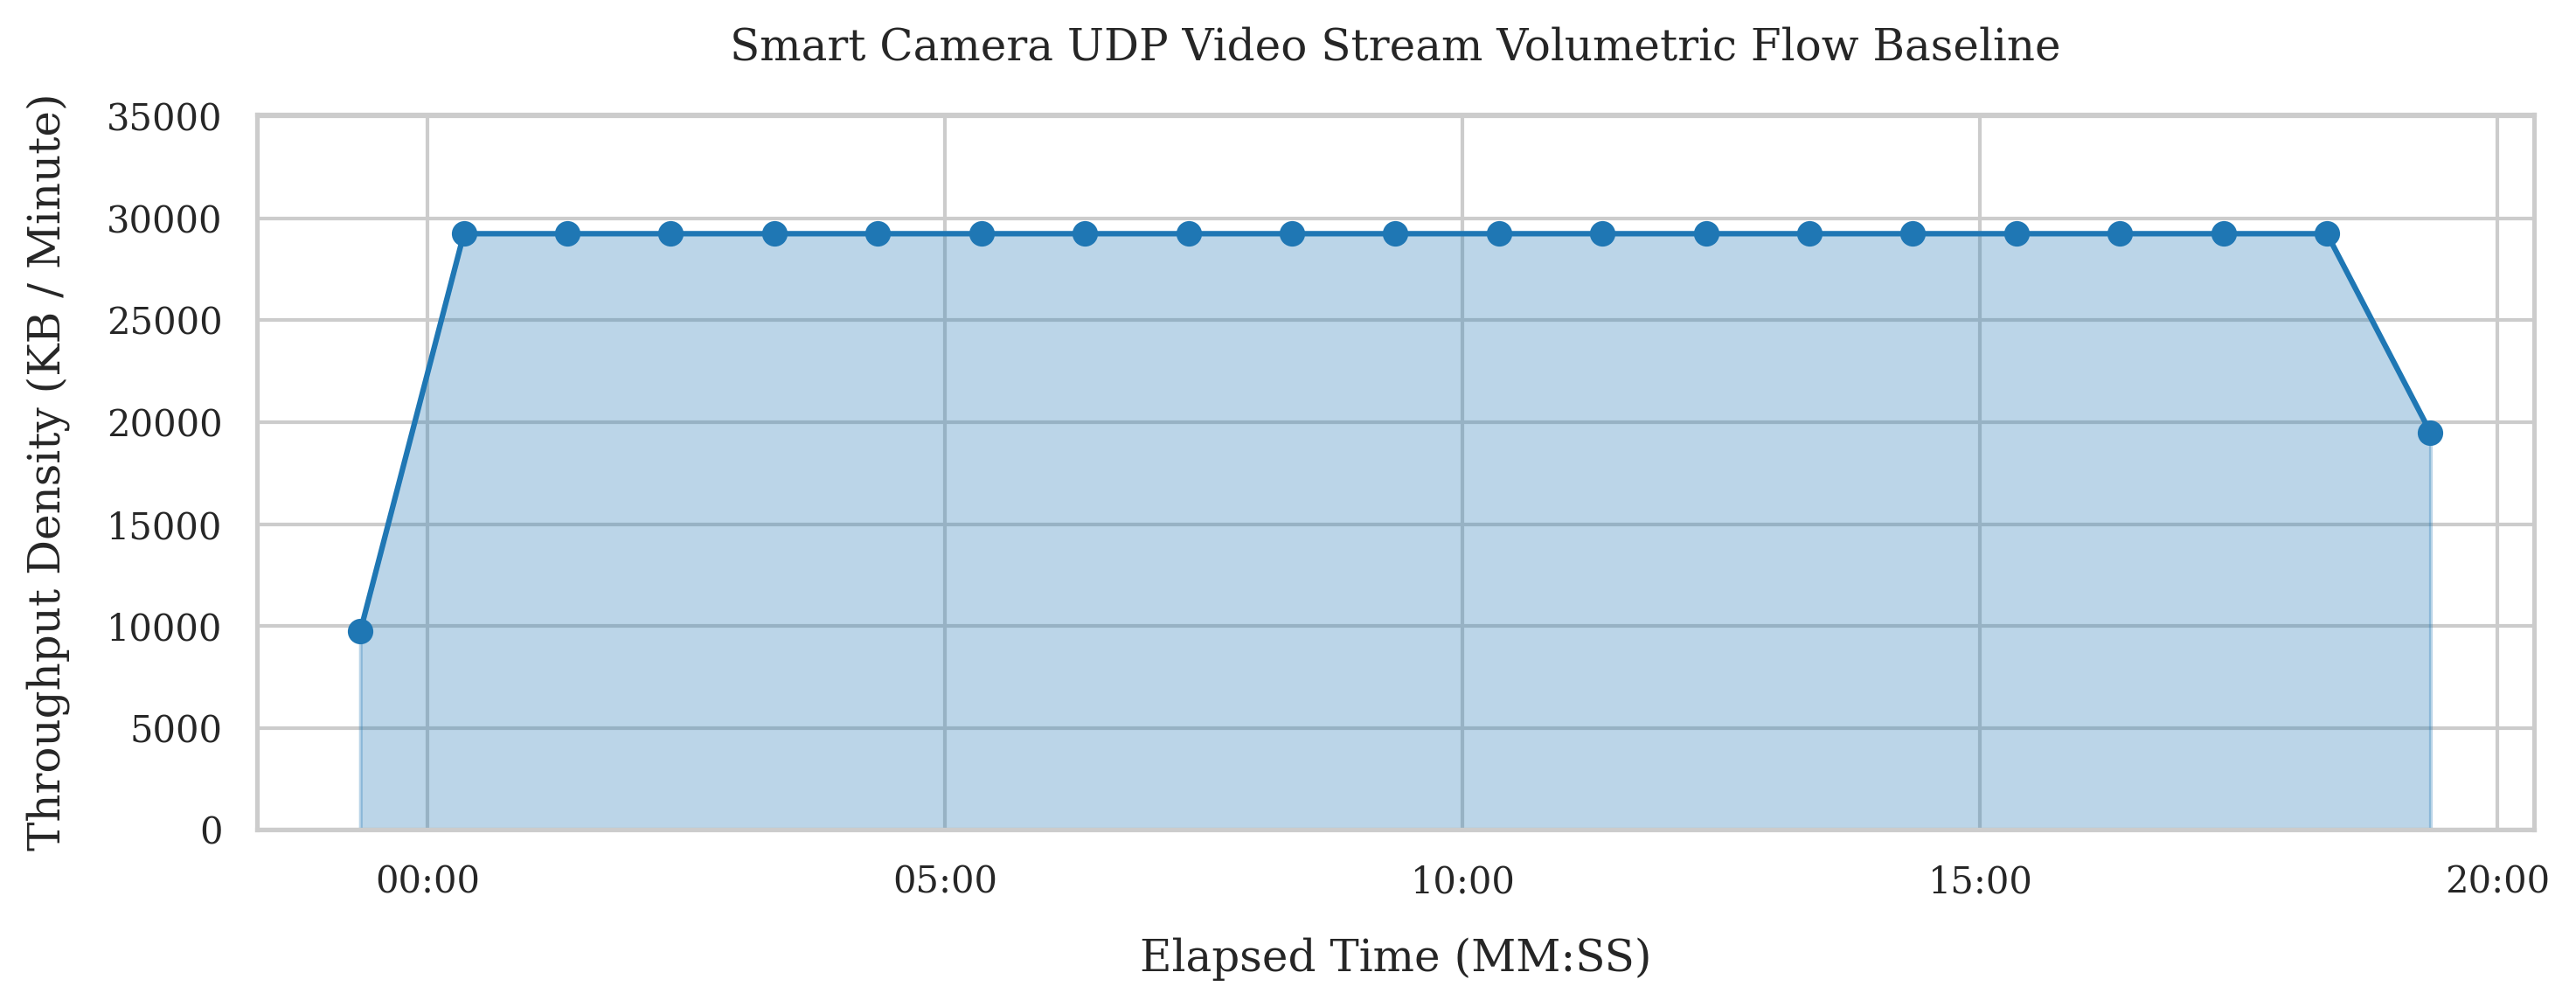

Empirical Average Bandwidth: 27,858.47 KB/minute
Target Bandwidth (4000K):       29,296.88 KB/minute


In [21]:
# Isolate the Camera UDP Feed
camera_udp = conn_df[(conn_df['id.orig_h'] == '10.0.0.1') & 
                     (conn_df['id.resp_p'] == 50005) & 
                     (conn_df['proto'] == 'udp')].copy()

# Fix Mininet 'any' interface double-counting for stateless UDP
camera_udp['orig_bytes'] = camera_udp['orig_bytes'] / 2

total_bytes = camera_udp['orig_bytes'].sum()
print(f"Camera Stream Total Originated Bytes: {total_bytes:,.0f} Bytes")

# ==========================================
# Universal Forensic Data Distribution
# ==========================================
# Get the global start and end of the entire capture
capture_start = conn_df.index.min()
capture_end = conn_df.index.max()

# Create a blank, continuous 1-second timeline for the whole capture
timeline = pd.Series(0.0, index=pd.date_range(start=capture_start, end=capture_end, freq='1s'))

# Dynamically distribute the bytes for EVERY row Zeek logged
for flow_start, row in camera_udp.iterrows():
    raw_duration = row['duration']
    
    # Safely extract duration handling NaNs and Timedeltas
    if pd.isna(raw_duration):
        duration_sec = 1.0
    elif isinstance(raw_duration, pd.Timedelta):
        duration_sec = raw_duration.total_seconds()
    else:
        duration_sec = float(raw_duration)
        
    if duration_sec <= 0: duration_sec = 1.0 # Prevent division by zero
        
    # Calculate bytes per second for this specific Zeek row
    bytes_per_sec = row['orig_bytes'] / duration_sec
    flow_end = flow_start + pd.Timedelta(seconds=duration_sec)
    
    # Slice the timeline and inject the bandwidth
    active_window = (timeline.index >= flow_start) & (timeline.index < flow_end)
    timeline.loc[active_window] += bytes_per_sec

# Resample our distributed 1-second timeline into 1-minute bins
volume_over_time = timeline.resample('1min').sum()


def parse_kbit_rate(rate: str) -> int:
    value = rate.strip().lower()
    if value.endswith('k'):
        return int(float(value[:-1]) * 1000)
    if value.endswith('m'):
        return int(float(value[:-1]) * 1000 * 1000)
    return int(float(value))

def expected_kb_per_min(rate: str) -> float:
    rate_bps = parse_kbit_rate(rate)
    return (rate_bps / 8.0) / 1024.0 * 60.0

# ==========================================
# Plotting (With Elapsed Time Fix)
# ==========================================
fig, ax = plt.subplots(figsize=(10, 4))
kb_values = volume_over_time.values / 1024

# Shift the timestamps so the graph starts at elapsed time 00:00
elapsed_time_index = volume_over_time.index - capture_start + pd.to_datetime('1970-01-01')

# Plot the area chart
ax.fill_between(elapsed_time_index, kb_values, color='#1f77b4', alpha=0.3)
ax.plot(elapsed_time_index, kb_values, marker='o', linestyle='-', color='#1f77b4', linewidth=1.5)

ax.set_title("Smart Camera UDP Video Stream Volumetric Flow Baseline", pad=15)
ax.set_xlabel("Elapsed Time (MM:SS)", labelpad=10)
ax.set_ylabel("Throughput Density (KB / Minute)", labelpad=10)

# Format the X-axis for elapsed minutes and seconds
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%M:%S'))

# Give the chart breathing room on top, handle edge cases if data is 0
top_limit = max(kb_values) * 1.2 if max(kb_values) > 0 else 1000
ax.set_ylim(bottom=0, top=top_limit) 

plt.tight_layout()
save_figure(fig, "camera_volumetric_flow")

plt.show()

# Print empirical average to terminal
avg_kb_min = kb_values[kb_values > 0].mean() if len(kb_values[kb_values > 0]) > 0 else 0
target_kb_min = expected_kb_per_min("4000K")
print(f"Empirical Average Bandwidth: {avg_kb_min:,.2f} KB/minute")
print(f"Target Bandwidth (4000K):       {target_kb_min:,.2f} KB/minute")

### Camera TLS Telemetry and Network Services
We check how often the camera phones home and how often the support services run.

In Scenario 4, these should remain close to baseline to isolate the anomaly to the thermostat.

In [22]:
# ==========================================
# INFRASTRUCTURE & BACKGROUND SERVICES VALIDATION
# ==========================================

expected_camera_tls = 5
expected_ntp_flows = 6
expected_dns_queries = 42

# Camera TLS Telemetry Verification
camera_tls = conn_df[
    (conn_df['id.orig_h'] == '10.0.0.1') &
    (conn_df['id.resp_p'] == 443) &
    (conn_df['proto'] == 'tcp')
]
print(f"Camera TLS Telemetry: {len(camera_tls)} flows (expected ~{expected_camera_tls})")

# Network Services (NTP) Verification
ntp_flows = conn_df[
    (conn_df['id.orig_h'].isin(['10.0.0.1', '10.0.0.2'])) &
    (conn_df['id.resp_p'] == 123) &
    (conn_df['proto'] == 'udp')
]
camera_ntp = len(ntp_flows[ntp_flows['id.orig_h'] == '10.0.0.1'])
therm_ntp = len(ntp_flows[ntp_flows['id.orig_h'] == '10.0.0.2'])
print(f"NTP Synchronization: {len(ntp_flows)} flows (expected ~{expected_ntp_flows})")
print(f"  Camera: {camera_ntp} | Thermostat: {therm_ntp}")

# Domain Name Resolution (DNS) Verification
dns_queries = dns_df[dns_df['id.orig_h'].isin(['10.0.0.1', '10.0.0.2'])]
print(f"DNS Queries: {len(dns_queries)} total (baseline ~{expected_dns_queries}, plus C2 in Scenario 4)")

Camera TLS Telemetry: 5 flows (expected ~5)
NTP Synchronization: 5 flows (expected ~6)
  Camera: 3 | Thermostat: 2
DNS Queries: 30 total (baseline ~42, plus C2 in Scenario 4)


### Camera Traffic Balance
We compare the camera's outgoing bytes with the bytes it receives.

Normal traffic should be mostly outgoing. If incoming traffic rises a lot, it can signal unusual control or remote access.

This check provides a stable reference while the thermostat exhibits botnet behavior.

In [23]:
# ==========================================
# Camera Directional Byte Ratio Analysis
# ==========================================

# Isolate all connections initiated by the Camera
camera_flows = conn_df[conn_df['id.orig_h'] == '10.0.0.1'].copy()

# Sum the Outbound (orig) and Inbound (resp) bytes securely
outbound_bytes = camera_flows['orig_bytes'].fillna(0).sum()
inbound_bytes = camera_flows['resp_bytes'].fillna(0).sum()
total_bytes = outbound_bytes + inbound_bytes

# Calculate the percentage distribution
if total_bytes > 0:
    outbound_ratio = (outbound_bytes / total_bytes) * 100
    inbound_ratio = (inbound_bytes / total_bytes) * 100
else:
    outbound_ratio = 0
    inbound_ratio = 0

# Professional Output Report
print("=== CAMERA DIRECTIONAL BYTE RATIO ===")
print(f"Total Traffic Volume: {total_bytes:,.0f} Bytes\n")

print(f"Outbound Transmitted (orig_bytes): {outbound_bytes:,.0f} Bytes ({outbound_ratio:.4f}%)")
print(f"Inbound Received (resp_bytes):     {inbound_bytes:,.0f} Bytes ({inbound_ratio:.4f}%)\n")

# Automated Tripwire
if outbound_ratio > 99.0:
    print("Baseline Validated: Traffic is highly asymmetric (>99% outbound), proving normal transmitter behavior.")
else:
    print("FORENSIC ALERT: High inbound volume detected! Potential Reverse Shell or C2 interaction.")

=== CAMERA DIRECTIONAL BYTE RATIO ===
Total Traffic Volume: 1,198,143,151 Bytes

Outbound Transmitted (orig_bytes): 1,198,140,463 Bytes (99.9998%)
Inbound Received (resp_bytes):     2,688 Bytes (0.0002%)

Baseline Validated: Traffic is highly asymmetric (>99% outbound), proving normal transmitter behavior.


## Thermostat Behavior

### Keep-Alives and Telemetry
We separate the thermostat's small keep-alive messages from its larger sensor updates and check that the pattern stays regular.

In Scenario 5, keep-alives may still be present, but botnet activity should introduce additional flows beyond MQTT.

In [24]:
# Isolate for Thermostat MQTT traffic (Enforcing TCP protocol)
thermostat_mqtt = conn_df[
    (conn_df['id.orig_h'] == '10.0.0.2') &
    (conn_df['id.resp_p'] == 8883) &
    (conn_df['proto'] == 'tcp')
] .copy()

# Sort by timestamp (index) to accurately calculate consecutive timing
thermostat_mqtt = thermostat_mqtt.sort_index()

# Separate Keep-Alives from Telemetry using a 20-byte threshold
# Handle NaN values in orig_bytes to prevent accidental row dropping
keep_alives = thermostat_mqtt[thermostat_mqtt['orig_bytes'].fillna(0) < 20].copy()
telemetry = thermostat_mqtt[thermostat_mqtt['orig_bytes'].fillna(0) >= 20].copy()

# Restrict keep-alives to the baseline window (first 300 seconds)
capture_start = conn_df.index.min()
baseline_end = capture_start + pd.Timedelta(seconds=300)
keep_alives = keep_alives[keep_alives.index <= baseline_end].copy()

# ---------------------------------------------------------
# Dynamic Ground Truth Validation (Partial-Window Aware)
# ---------------------------------------------------------
# Calculate the exact span for each subset to handle truncated phases
keep_alive_span = (
    (keep_alives.index.max() - keep_alives.index.min()).total_seconds()
    if len(keep_alives) > 0 else 0
 )
telemetry_span = (
    (telemetry.index.max() - telemetry.index.min()).total_seconds()
    if len(telemetry) > 0 else 0
 )

keep_alive_interval = 10.0
telemetry_interval = 300.0

# The +1 accounts for the initial packet sent at t=0 within each span
expected_keep_alives = int(keep_alive_span / keep_alive_interval) + 1 if keep_alive_span > 0 else 0
expected_telemetry = int(telemetry_span / telemetry_interval) + 1 if telemetry_span > 0 else 0

print("=== MQTT BEHAVIORAL VALIDATION ===")
print(f"Keep-Alive Span: {keep_alive_span:.2f} seconds")
print(f"Telemetry Span:  {telemetry_span:.2f} seconds\n")
print(f"Keep-Alives Observed: {len(keep_alives)} (Target: ~{expected_keep_alives})")
print(f"Telemetry Observed:   {len(telemetry)} (Target: ~{expected_telemetry})\n")

# ---------------------------------------------------------
# Inter-Arrival Time (IAT) Calculation
# ---------------------------------------------------------
# Calculate time difference between consecutive keep-alive rows
keep_alives['IAT'] = keep_alives.index.to_series().diff().dt.total_seconds()

# Drop the first row's NaN IAT before doing statistical math
iat_clean = keep_alives['IAT'].dropna()
iat_mean = iat_clean.mean() if len(iat_clean) > 0 else 0
iat_var = iat_clean.var() if len(iat_clean) > 1 else 0

print("--- Temporal Fingerprint (Keep-Alives) ---")
print(f"IAT Mean:     {iat_mean:.4f} seconds")
print(f"IAT Variance: {iat_var:.6f}\n")

# ---------------------------------------------------------
# Non-MQTT Thermostat Activity
# ---------------------------------------------------------
therm_non_mqtt = conn_df[
    (conn_df['id.orig_h'] == '10.0.0.2') &
    (~conn_df['id.resp_p'].isin([53, 123, 8883]))
]
print(f"Non-MQTT Thermostat Flows (not DNS/NTP/MQTT): {len(therm_non_mqtt)}")

=== MQTT BEHAVIORAL VALIDATION ===
Keep-Alive Span: 290.02 seconds
Telemetry Span:  300.04 seconds

Keep-Alives Observed: 30 (Target: ~30)
Telemetry Observed:   2 (Target: ~2)

--- Temporal Fingerprint (Keep-Alives) ---
IAT Mean:     10.0008 seconds
IAT Variance: 0.000082

Non-MQTT Thermostat Flows (not DNS/NTP/MQTT): 114


### Keep-Alive Timing
We plot the time between thermostat keep-alives to see if they arrive on a steady schedule.

In Scenario 5, keep-alives can still be regular, but botnet activity may introduce jitter or gaps.

Saved figure: ../../figures/scenario4/thermostat_iat_distribution.pdf and ../../figures/scenario4/thermostat_iat_distribution.png


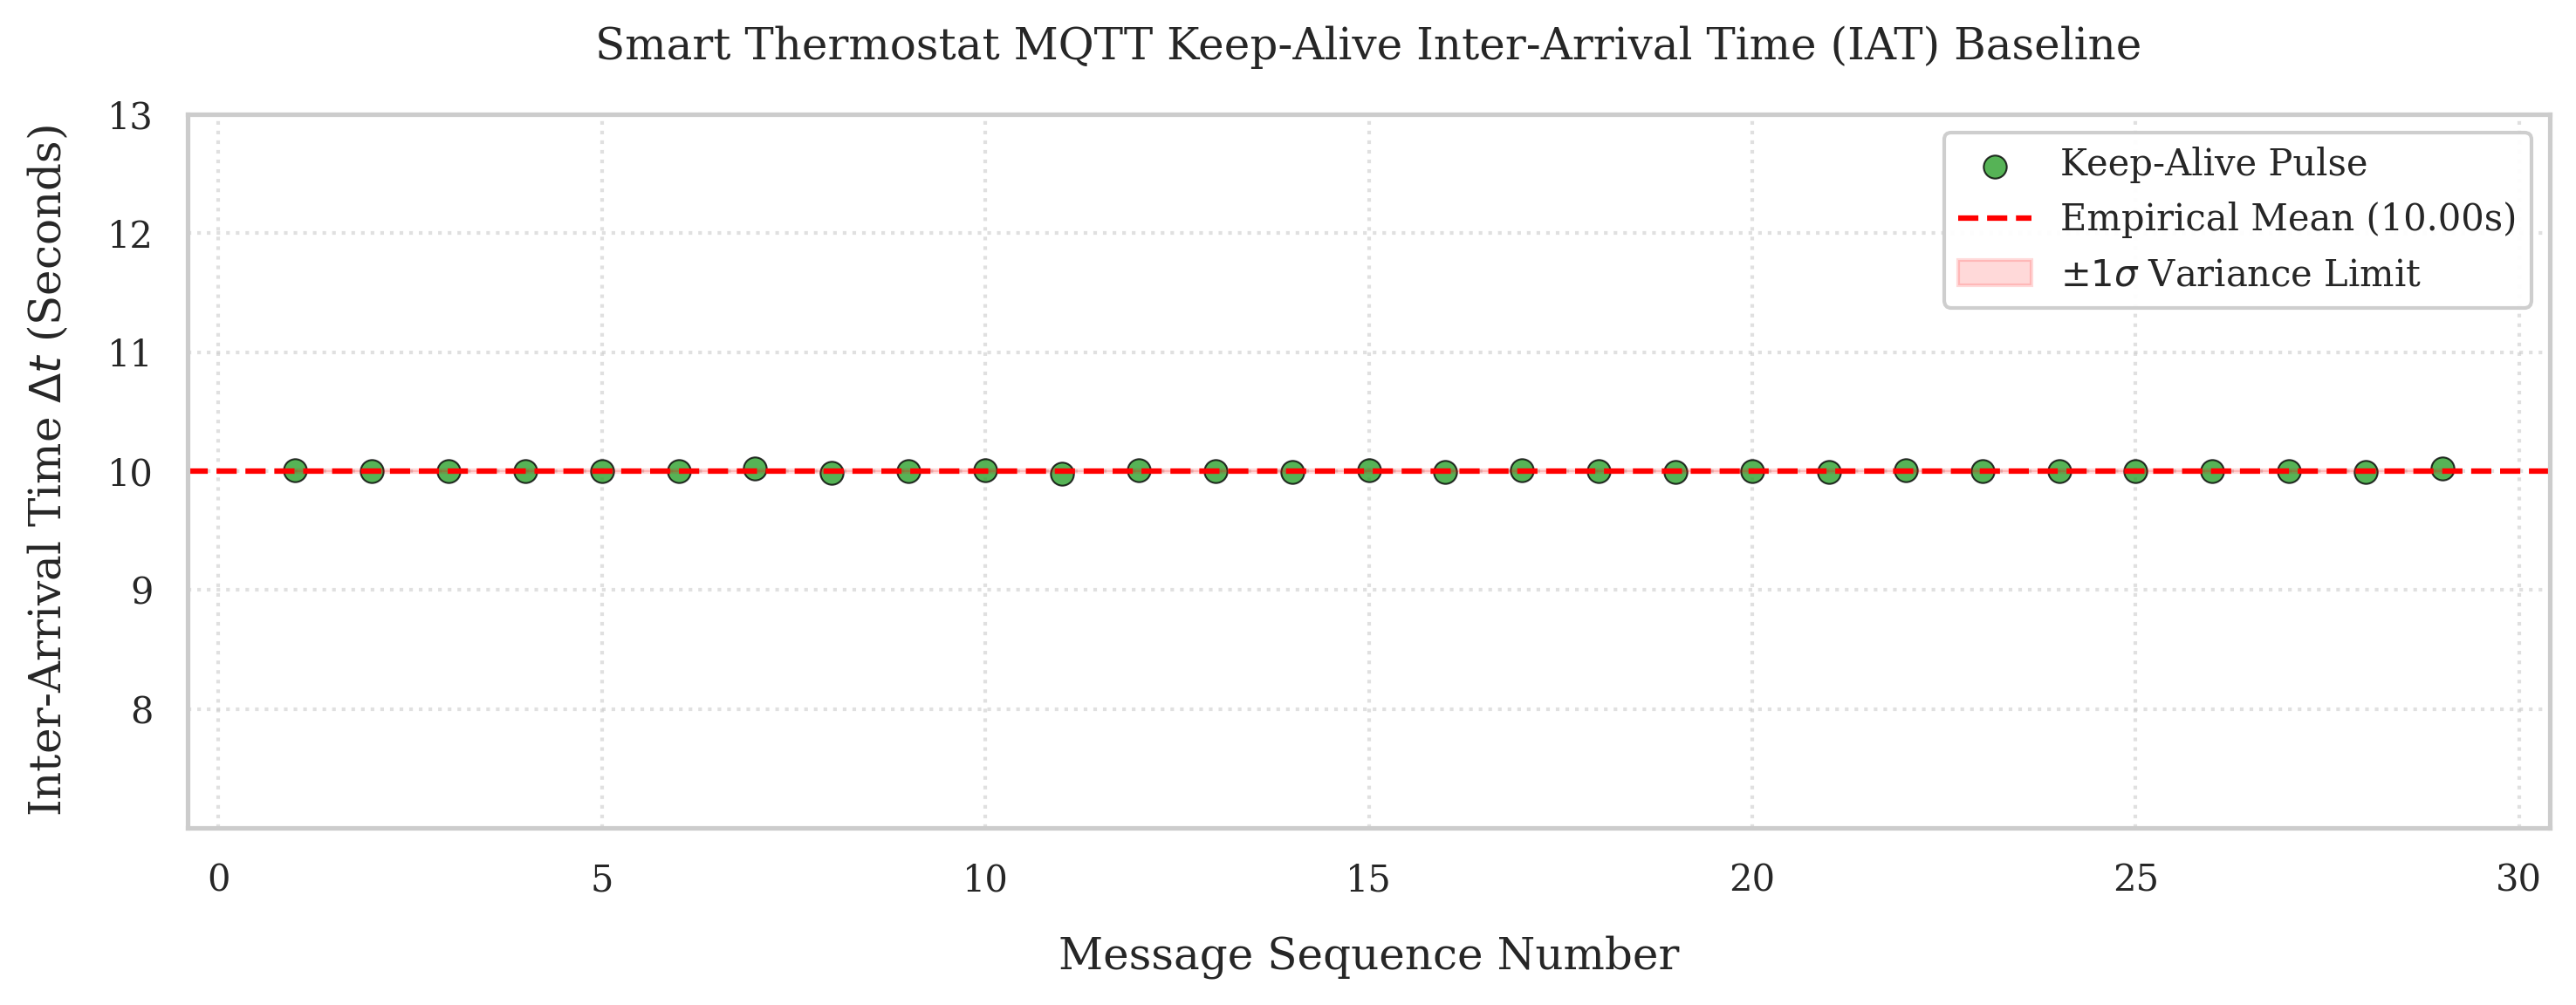

IAT Scatter Plot Generated.
   - Mapped 29 sequential pulses.
   - Empirical Mean: 10.0008s | Standard Deviation: 0.0091s


In [25]:
# Clean the NaN value from the first row (the initial fencepost packet)
plot_data = keep_alives.dropna(subset=['IAT']).copy()

# Re-sequence from 1 to N after dropping the first row
plot_data['Sequence'] = range(1, len(plot_data) + 1)

# Calculate plotting statistics
iat_mean = plot_data['IAT'].mean()
iat_std = plot_data['IAT'].std()

# Academic Plotting
fig, ax = plt.subplots(figsize=(10, 4))

# Plot the individual IAT events
ax.scatter(plot_data['Sequence'], plot_data['IAT'], 
           color='#2ca02c', alpha=0.8, edgecolors='black', linewidth=0.5, s=40, label='Keep-Alive Pulse')

# Plot the empirical mean
ax.axhline(y=iat_mean, color='red', linestyle='--', linewidth=1.5, label=f"Empirical Mean ({iat_mean:.2f}s)")

# Add a shaded band for +/- 1 Standard Deviation to visually prove the near-zero variance
ax.fill_between(plot_data['Sequence'], 
                iat_mean - iat_std, 
                iat_mean + iat_std, 
                color='red', alpha=0.15, label=r'$\pm 1\sigma$ Variance Limit')

ax.set_title("Smart Thermostat MQTT Keep-Alive Inter-Arrival Time (IAT) Baseline", pad=15)
ax.set_xlabel("Message Sequence Number", labelpad=10)
ax.set_ylabel("Inter-Arrival Time $\Delta t$ (Seconds)", labelpad=10)

# Add a subtle grid to make temporal deviations easy to spot
ax.grid(True, linestyle=':', alpha=0.6)

# Focus the Y-axis tightly around the expected baseline to highlight stability
ax.set_ylim(bottom=max(0, iat_mean - 3), top=iat_mean + 3) 

# Place the legend neatly in the corner
ax.legend(loc="upper right", framealpha=0.95)

plt.tight_layout()
save_figure(fig, "thermostat_iat_distribution")

plt.show()

print(f"IAT Scatter Plot Generated.")
print(f"   - Mapped {len(plot_data)} sequential pulses.")
print(f"   - Empirical Mean: {iat_mean:.4f}s | Standard Deviation: {iat_std:.4f}s")

### Telemetry Size
We measure how large the thermostat's sensor messages are.

They should stay close in size. If they inflate or become highly variable, it can indicate payload stuffing during compromise.

In [26]:
# ==========================================
# Thermostat Telemetry Payload Footprinting
# ==========================================

# Extract the byte sizes of the telemetry packets (>= 20 bytes)
# We use the 'telemetry' dataframe previously generated in the IAT cell
payload_sizes = telemetry['orig_bytes'].dropna()

# Calculate the statistical footprint
payload_mean = payload_sizes.mean()

# Variance requires at least 2 packets. If identical, variance is mathematically 0.0
payload_var = payload_sizes.var() if len(payload_sizes) > 1 else 0.0

# Min/Max boundary detection
payload_min = payload_sizes.min()
payload_max = payload_sizes.max()

# Professional Output Report
print("=== MQTT TELEMETRY PAYLOAD FOOTPRINT ===")
print(f"Total Telemetry Reports Analyzed: {len(payload_sizes)}\n")

print(f"Empirical Mean Size: {payload_mean:.2f} Bytes")
print(f"Payload Variance:    {payload_var:.4f}")
print(f"Observed Range:      {payload_min:.0f} Bytes to {payload_max:.0f} Bytes\n")

# Automated Tripwire
# A variance of less than 5 indicates extreme structural rigidity (expected for M2M)
if payload_var < 5.0:
    print("Baseline Validated: Telemetry payloads are structurally rigid and predictable.")
else:
    print("FORENSIC ALERT: High payload variance detected! Potential data exfiltration or payload stuffing.")

=== MQTT TELEMETRY PAYLOAD FOOTPRINT ===
Total Telemetry Reports Analyzed: 2

Empirical Mean Size: 27.00 Bytes
Payload Variance:    0.0000
Observed Range:      27 Bytes to 27 Bytes

Baseline Validated: Telemetry payloads are structurally rigid and predictable.


## Botnet Indicators

We extract explicit signals of compromise: C2 resolution, IRC-style check-ins, lateral scans, and volumetric UDP bursts.
The C2 server is `203.0.113.10`, and the DDoS victim is `203.0.113.99`.

In [27]:
# ==========================================
# 4.1 C2 DNS and IRC Check-In
# ==========================================

capture_start = conn_df.index.min()

if 'query' in dns_df.columns:
    c2_dns = dns_df[dns_df['query'] == 'c2.botnet.com'].copy()
else:
    c2_dns = pd.DataFrame()

c2_tcp = conn_df[
    (conn_df['id.orig_h'] == '10.0.0.2') &
    (conn_df['id.resp_p'] == 6667) &
    (conn_df['proto'] == 'tcp')
] .copy()

print("=== C2 CHECK-IN REPORT ===")
print(f"C2 DNS Lookups (c2.botnet.com): {len(c2_dns)}")
print(f"C2 TCP Check-ins (TCP/6667):     {len(c2_tcp)}\n")

if len(c2_dns) > 0:
    c2_dns['elapsed_s'] = (c2_dns.index - capture_start).total_seconds()
    display(c2_dns[['id.orig_h', 'query', 'elapsed_s']].head(10))

if len(c2_tcp) > 0:
    c2_tcp = c2_tcp.sort_index()
    c2_tcp['elapsed_s'] = (c2_tcp.index - capture_start).total_seconds()
    display(c2_tcp[['id.orig_h', 'id.resp_h', 'id.resp_p', 'conn_state', 'elapsed_s']].head(10))

=== C2 CHECK-IN REPORT ===
C2 DNS Lookups (c2.botnet.com): 3
C2 TCP Check-ins (TCP/6667):     18



,id.orig_h,query,elapsed_s
ts,,,
2026-05-25 19:01:39.158540964,10.0.0.2,c2.botnet.com,300.130939
2026-05-25 19:01:39.161648035,10.0.0.2,c2.botnet.com,300.134046
2026-05-25 19:01:39.162841082,10.0.0.2,c2.botnet.com,300.135239


,id.orig_h,id.resp_h,id.resp_p,conn_state,elapsed_s
ts,,,,,
2026-05-25 19:01:39.213063002,10.0.0.2,203.0.113.10,6667,S1,300.185461
2026-05-25 19:03:19.187417030,10.0.0.2,10.0.0.1,6667,REJ,400.159815
2026-05-25 19:03:19.369544983,10.0.0.2,10.0.0.3,6667,REJ,400.341943
2026-05-25 19:03:45.357462883,10.0.0.2,10.0.0.1,6667,REJ,426.329861
2026-05-25 19:03:45.545090914,10.0.0.2,10.0.0.3,6667,REJ,426.517489
2026-05-25 19:04:11.231870890,10.0.0.2,10.0.0.1,6667,REJ,452.204269
2026-05-25 19:04:11.431742907,10.0.0.2,10.0.0.3,6667,REJ,452.404141
2026-05-25 19:04:36.554577112,10.0.0.2,10.0.0.1,6667,REJ,477.526975
2026-05-25 19:04:36.737718105,10.0.0.2,10.0.0.3,6667,REJ,477.710116


=== LATERAL SCAN REPORT ===
Total Lateral Flows: 128
conn_state
REJ    128
OTH      0
S0       0
S1       0
SF       0
Name: count, dtype: int64


Saved figure: ../../figures/scenario4/lateral_scan_density.pdf and ../../figures/scenario4/lateral_scan_density.png


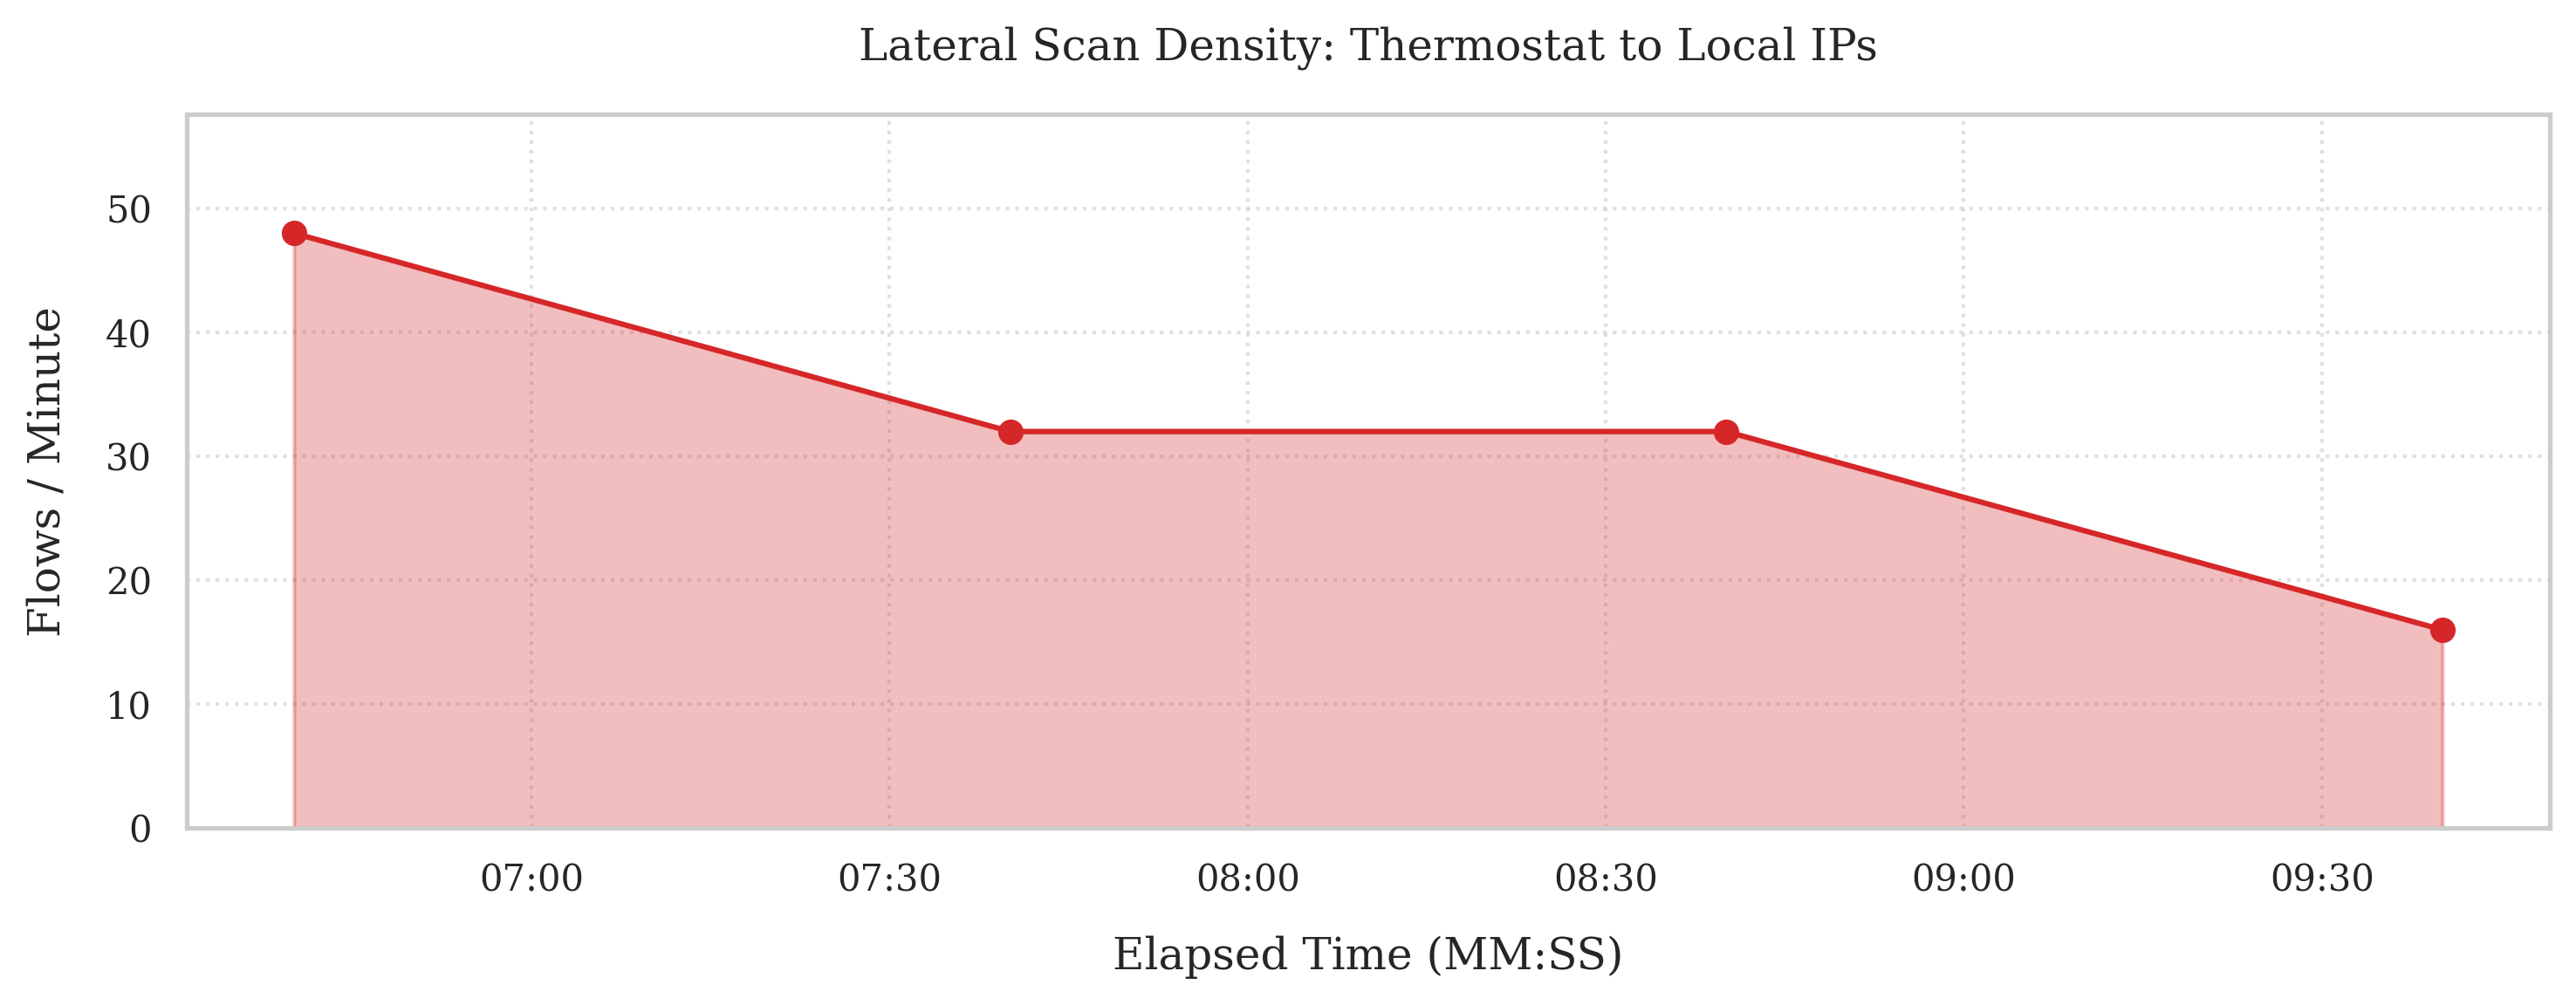

In [28]:
# ==========================================
# 4.2 Lateral Scan Burst (Thermostat -> Local)
# ==========================================

lateral_targets = ['10.0.0.1', '10.0.0.3']
lateral_flows = conn_df[
    (conn_df['id.orig_h'] == '10.0.0.2') &
    (conn_df['id.resp_h'].isin(lateral_targets)) &
    (conn_df['proto'] == 'tcp')
] .copy()

print("=== LATERAL SCAN REPORT ===")
print(f"Total Lateral Flows: {len(lateral_flows)}")
if len(lateral_flows) > 0:
    print(lateral_flows['conn_state'].value_counts())

# Plot lateral flow density per minute
lateral_per_min = lateral_flows['uid'].resample('1min', origin='start').count()
capture_start = conn_df.index.min()
elapsed_time_index = lateral_per_min.index - capture_start + pd.to_datetime('1970-01-01')

fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(elapsed_time_index, lateral_per_min.values, color='#d62728', alpha=0.3)
ax.plot(elapsed_time_index, lateral_per_min.values, color='#d62728', marker='o', linestyle='-', linewidth=1.5)
ax.set_title("Lateral Scan Density: Thermostat to Local IPs", pad=15)
ax.set_xlabel("Elapsed Time (MM:SS)", labelpad=10)
ax.set_ylabel("Flows / Minute", labelpad=10)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%M:%S'))
ax.grid(True, linestyle=':', alpha=0.6)
ax.set_ylim(bottom=0, top=max(5, lateral_per_min.max() * 1.2))

plt.tight_layout()
save_figure(fig, "lateral_scan_density")
plt.show()

=== THERMOSTAT UDP FLOOD CHECK ===
Total Thermostat UDP Flows (to 203.0.113.99): 1
Saved figure: ../../figures/scenario4/thermostat_udp_throughput.pdf and ../../figures/scenario4/thermostat_udp_throughput.png


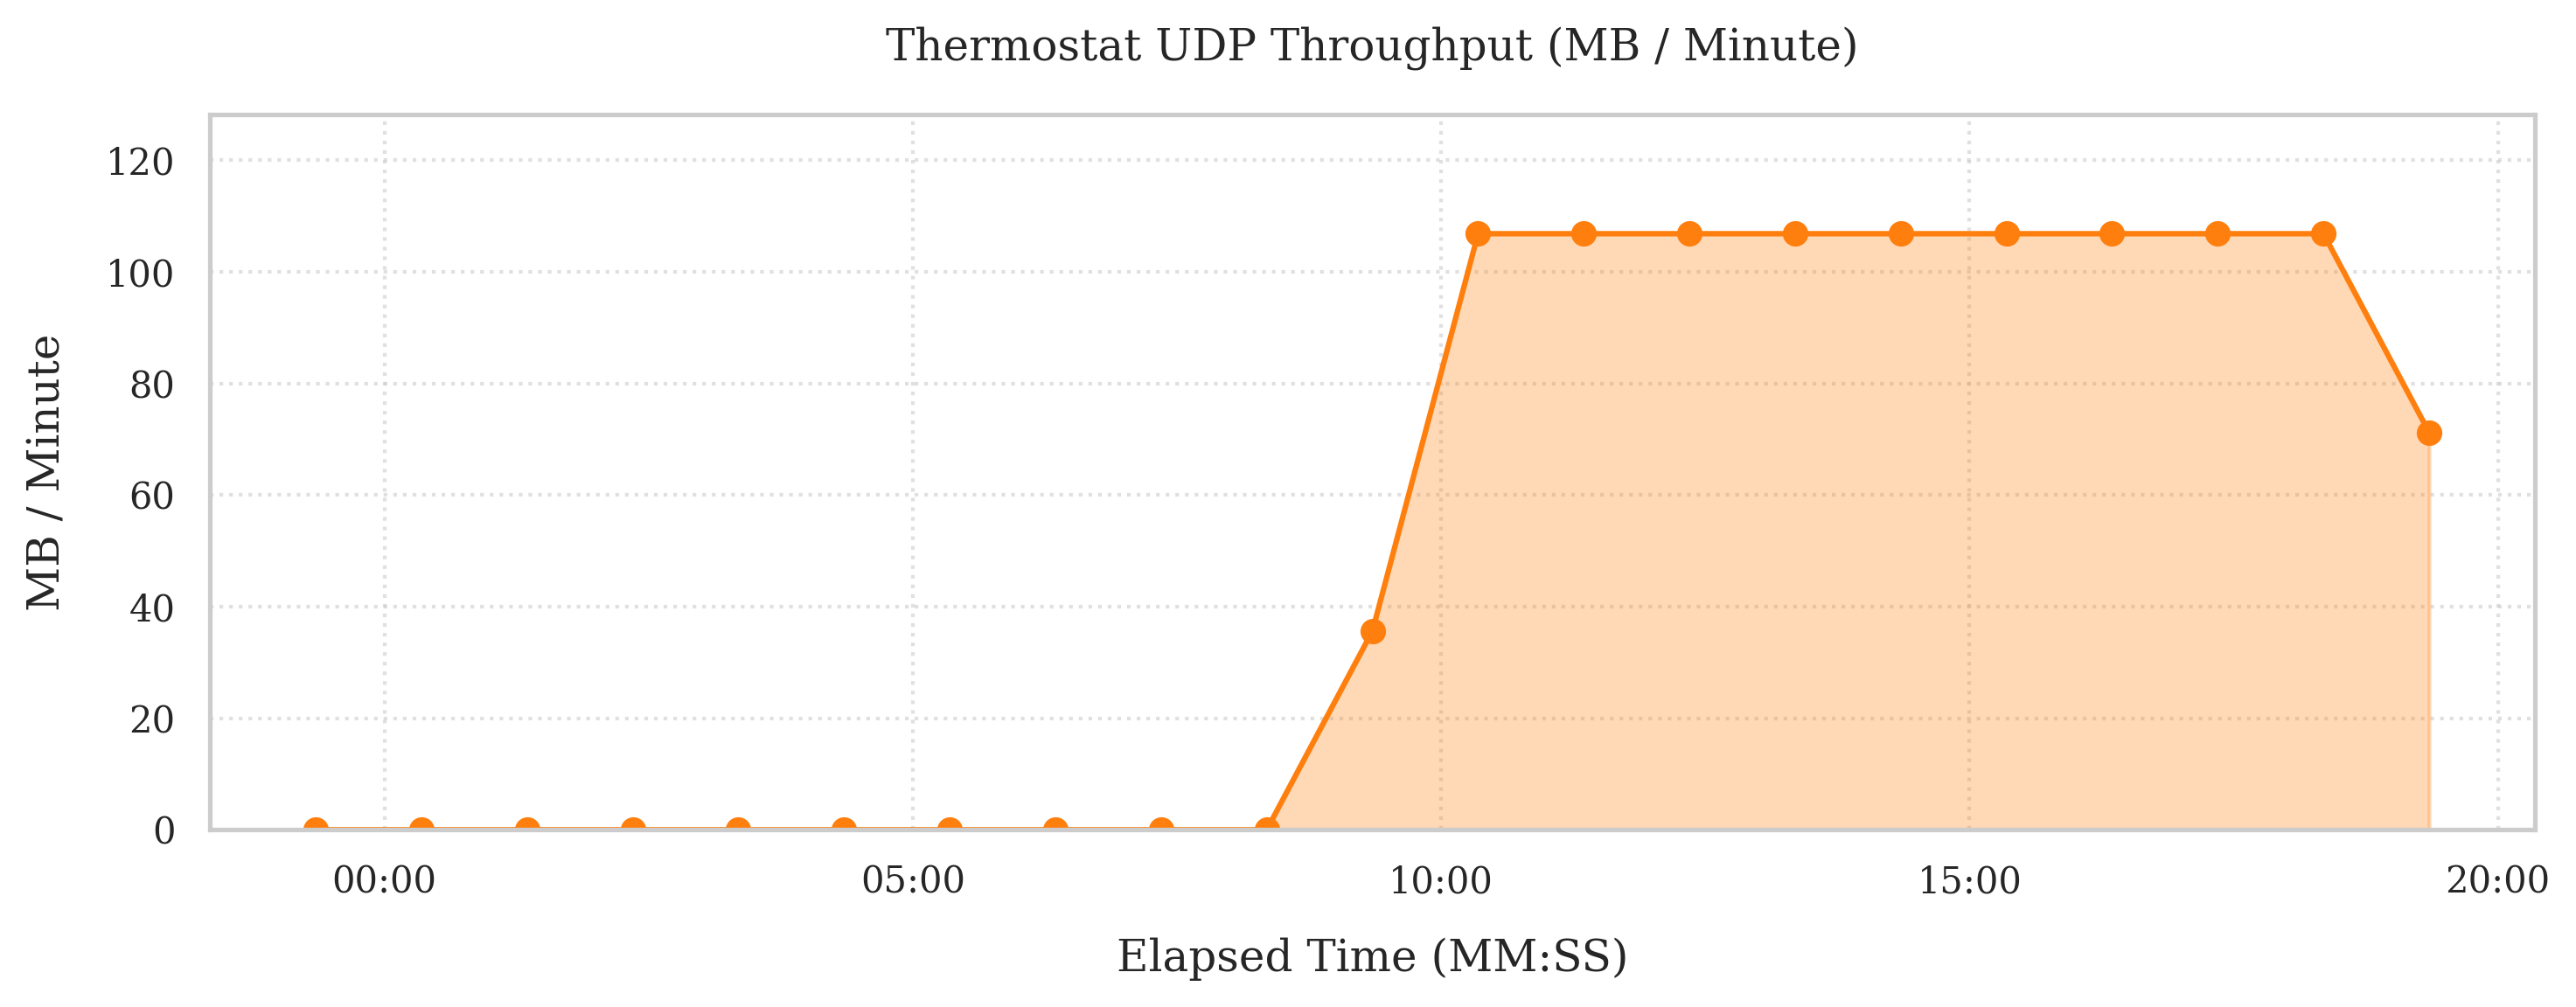

Peak UDP Volume: 106.80 MB/min


In [29]:
# ==========================================
# 4.3 Thermostat UDP Flood Check
# ==========================================

therm_udp = conn_df[
    (conn_df['id.orig_h'] == '10.0.0.2') &
    (conn_df['proto'] == 'udp') &
    (conn_df['id.resp_h'] == '203.0.113.99')
] .copy()

print("=== THERMOSTAT UDP FLOOD CHECK ===")
print(f"Total Thermostat UDP Flows (to 203.0.113.99): {len(therm_udp)}")

if len(therm_udp) == 0:
    print("No thermostat UDP flood flows detected in this capture.")
else:
    capture_start = conn_df.index.min()
    capture_end = conn_df.index.max()
    timeline = pd.Series(0.0, index=pd.date_range(start=capture_start, end=capture_end, freq='1s'))

    for flow_start, row in therm_udp.iterrows():
        raw_duration = row['duration']
        if pd.isna(raw_duration):
            duration_sec = 1.0
        elif isinstance(raw_duration, pd.Timedelta):
            duration_sec = raw_duration.total_seconds()
        else:
            duration_sec = float(raw_duration)
        if duration_sec <= 0:
            duration_sec = 1.0

        bytes_per_sec = row['orig_bytes'] / duration_sec if pd.notna(row['orig_bytes']) else 0
        flow_end = flow_start + pd.Timedelta(seconds=duration_sec)
        active_window = (timeline.index >= flow_start) & (timeline.index < flow_end)
        timeline.loc[active_window] += bytes_per_sec

    udp_volume_per_min = timeline.resample('1min').sum() / 1024 / 1024
    elapsed_time_index = udp_volume_per_min.index - capture_start + pd.to_datetime('1970-01-01')

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.fill_between(elapsed_time_index, udp_volume_per_min.values, color='#ff7f0e', alpha=0.3)
    ax.plot(elapsed_time_index, udp_volume_per_min.values, color='#ff7f0e', marker='o', linestyle='-', linewidth=1.5)
    ax.set_title("Thermostat UDP Throughput (MB / Minute)", pad=15)
    ax.set_xlabel("Elapsed Time (MM:SS)", labelpad=10)
    ax.set_ylabel("MB / Minute", labelpad=10)
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%M:%S'))
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.set_ylim(bottom=0, top=max(1, udp_volume_per_min.max() * 1.2))

    plt.tight_layout()
    save_figure(fig, "thermostat_udp_throughput")
    plt.show()

    print(f"Peak UDP Volume: {udp_volume_per_min.max():.2f} MB/min")

## Network Health

### TCP Connection States
We look at the main TCP states to see whether the network is behaving normally.

In Scenario 4, we expect a surge in `REJ` and `S0` caused by lateral scanning from the thermostat.

Saved figure: ../../figures/scenario4/tcp_connection_states.pdf and ../../figures/scenario4/tcp_connection_states.png


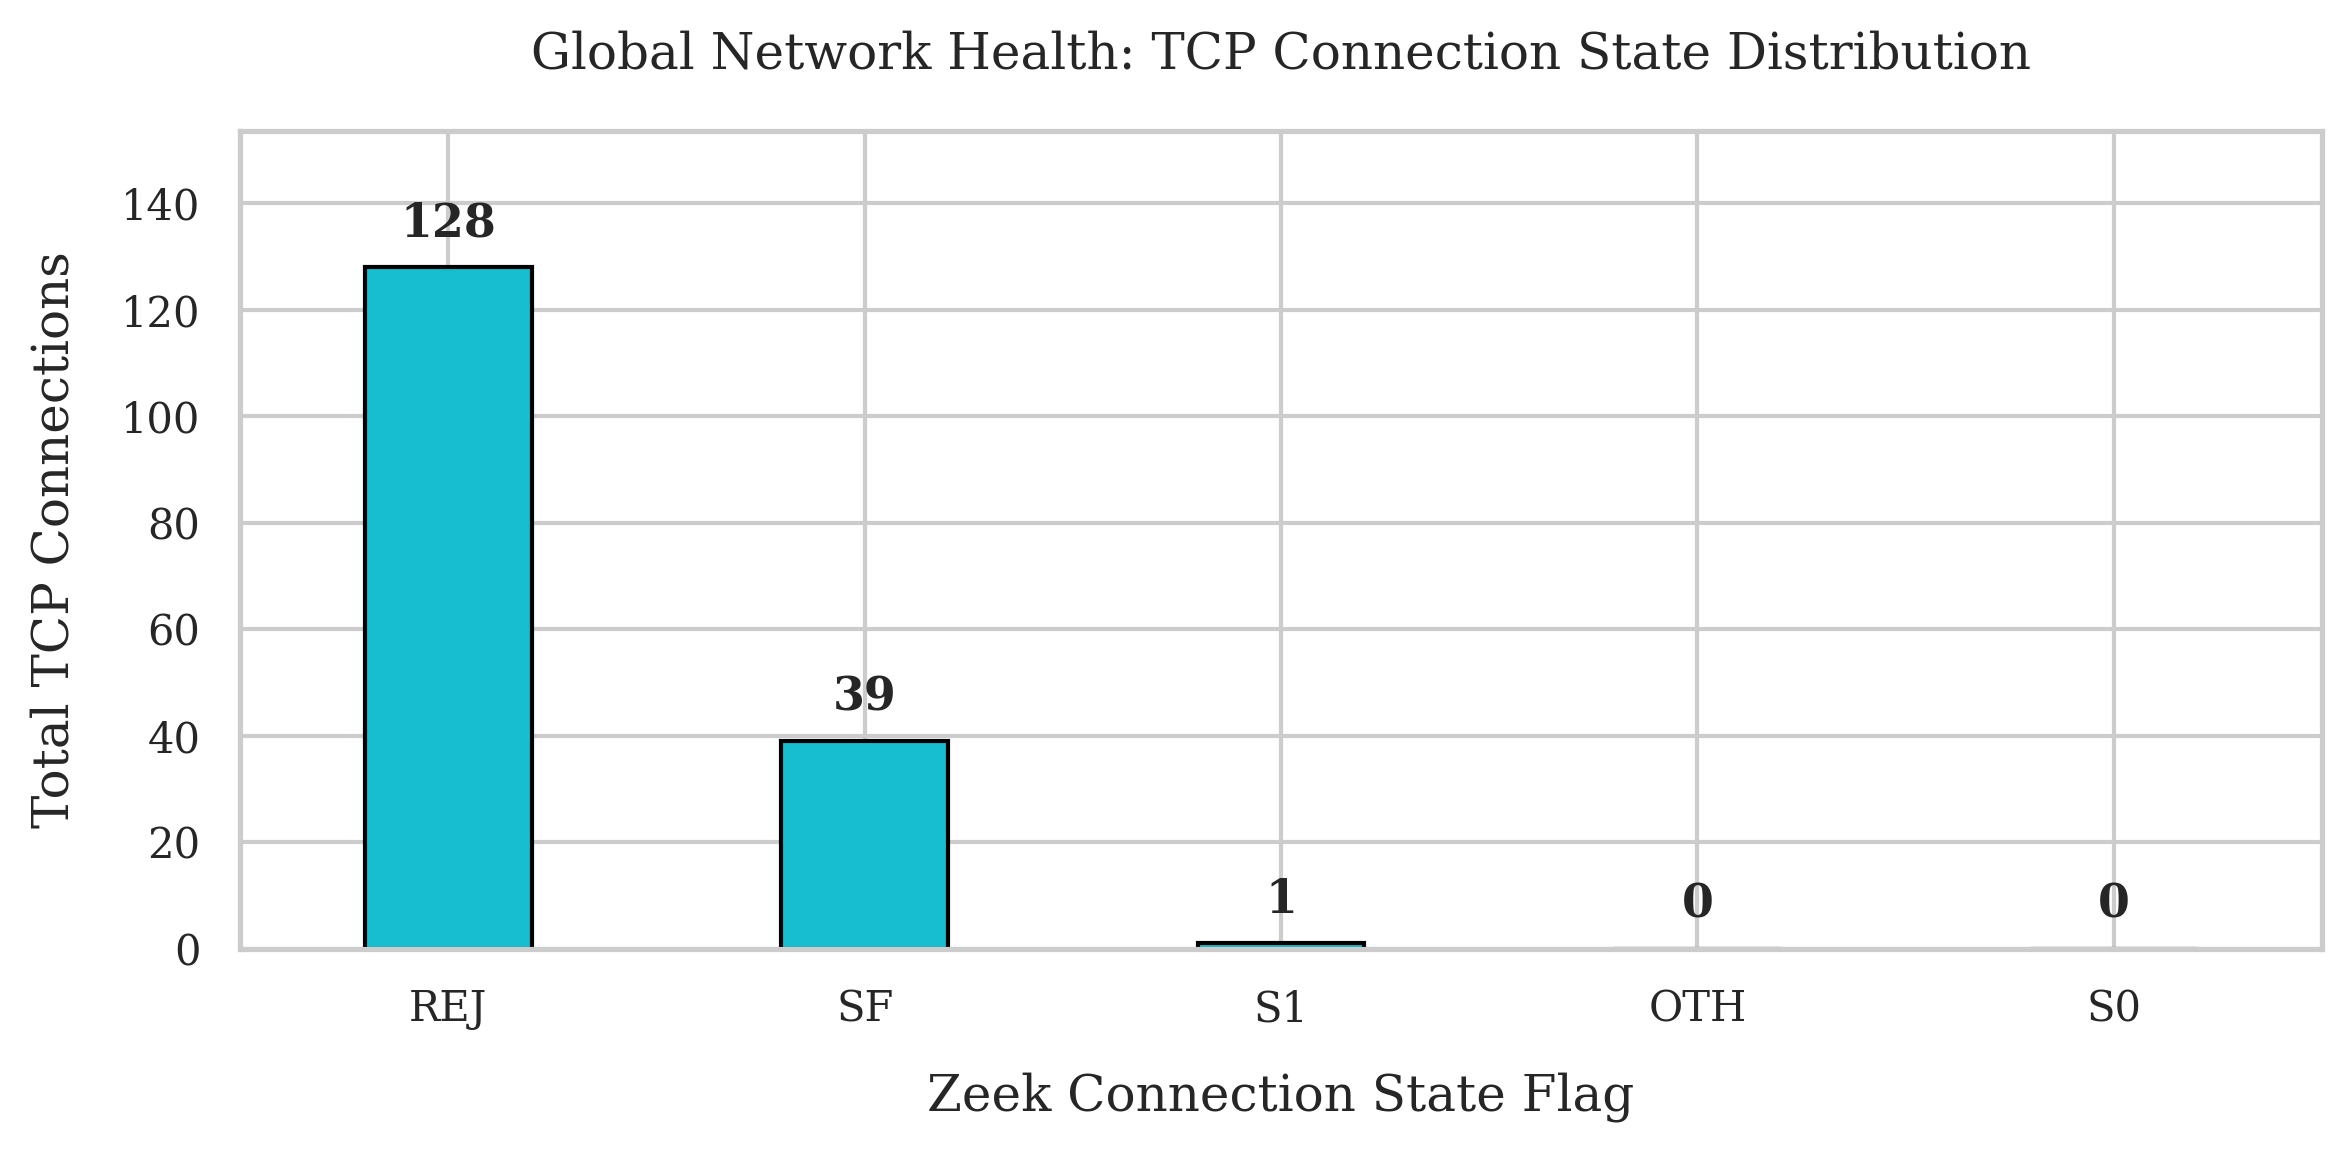

=== TCP STATE FORENSIC REPORT ===
Total TCP Flows Analyzed: 168

[REJ] : 128 Flows -> Connection attempt rejected by responder (RST sent).
[SF] : 39 Flows -> Normal establishment and termination (Clean Teardown).
[S1] : 1 Flows -> Connection established, not terminated (Persistent Socket).
[OTH] : 0 Flows -> No SYN seen, just mid-stream traffic (Asymmetric routing).
[S0] : 0 Flows -> Connection attempt seen, no reply (Scanner / Blocked).


In [30]:
# ==========================================
# 5.1 Global Network Health (TCP States)
# ==========================================

# Isolate ONLY TCP traffic
tcp_df = conn_df[conn_df['proto'] == 'tcp'].copy()

# Compute state distribution
state_counts = tcp_df['conn_state'].value_counts()

# Academic Plotting
fig, ax = plt.subplots(figsize=(8, 4)) # Slightly wider to accommodate labels

# Use a distinct color palette
state_counts.plot(kind='bar', color='#17becf', ax=ax, width=0.4, edgecolor='black')

ax.set_title("Global Network Health: TCP Connection State Distribution", pad=15)
ax.set_xlabel("Zeek Connection State Flag", labelpad=10)
ax.set_ylabel("Total TCP Connections", labelpad=10)

# Explicitly set the x-axis limits to give a single bar breathing room
ax.set_xlim(-0.5, len(state_counts) - 0.5)
plt.xticks(rotation=0)

# Bulletproof text annotation layer
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}',
                xy=(p.get_x() + p.get_width() / 2, height),
                xytext=(0, 5),  # 5 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=11, weight='bold')

# Ensure the Y-axis has room for the top annotation
ax.set_ylim(0, state_counts.max() * 1.2)

plt.tight_layout()
save_figure(fig, "tcp_connection_states")
plt.show()

# ---------------------------------------------------------
# Automated Contextual Reporting
# ---------------------------------------------------------
# A reference dictionary mapping Zeek states to their physical network reality
zeek_state_definitions = {
    'SF': 'Normal establishment and termination (Clean Teardown).',
    'S0': 'Connection attempt seen, no reply (Scanner / Blocked).',
    'S1': 'Connection established, not terminated (Persistent Socket).',
    'REJ': 'Connection attempt rejected by responder (RST sent).',
    'RSTO': 'Connection established, originator aborted (RST sent).',
    'RSTR': 'Established, responder aborted (RST sent).',
    'OTH': 'No SYN seen, just mid-stream traffic (Asymmetric routing).',
}

print("=== TCP STATE FORENSIC REPORT ===")
print(f"Total TCP Flows Analyzed: {len(tcp_df)}\n")

for state, count in state_counts.items():
    definition = zeek_state_definitions.get(state, "Unknown state.")
    print(f"[{state}] : {count:,.0f} Flows -> {definition}")

### Flow Rate
We count how many new connections appear each minute.

In Scenario 4, the lateral scan and DDoS activity should create visible spikes.

Saved figure: ../../figures/scenario4/network_flow_density.pdf and ../../figures/scenario4/network_flow_density.png


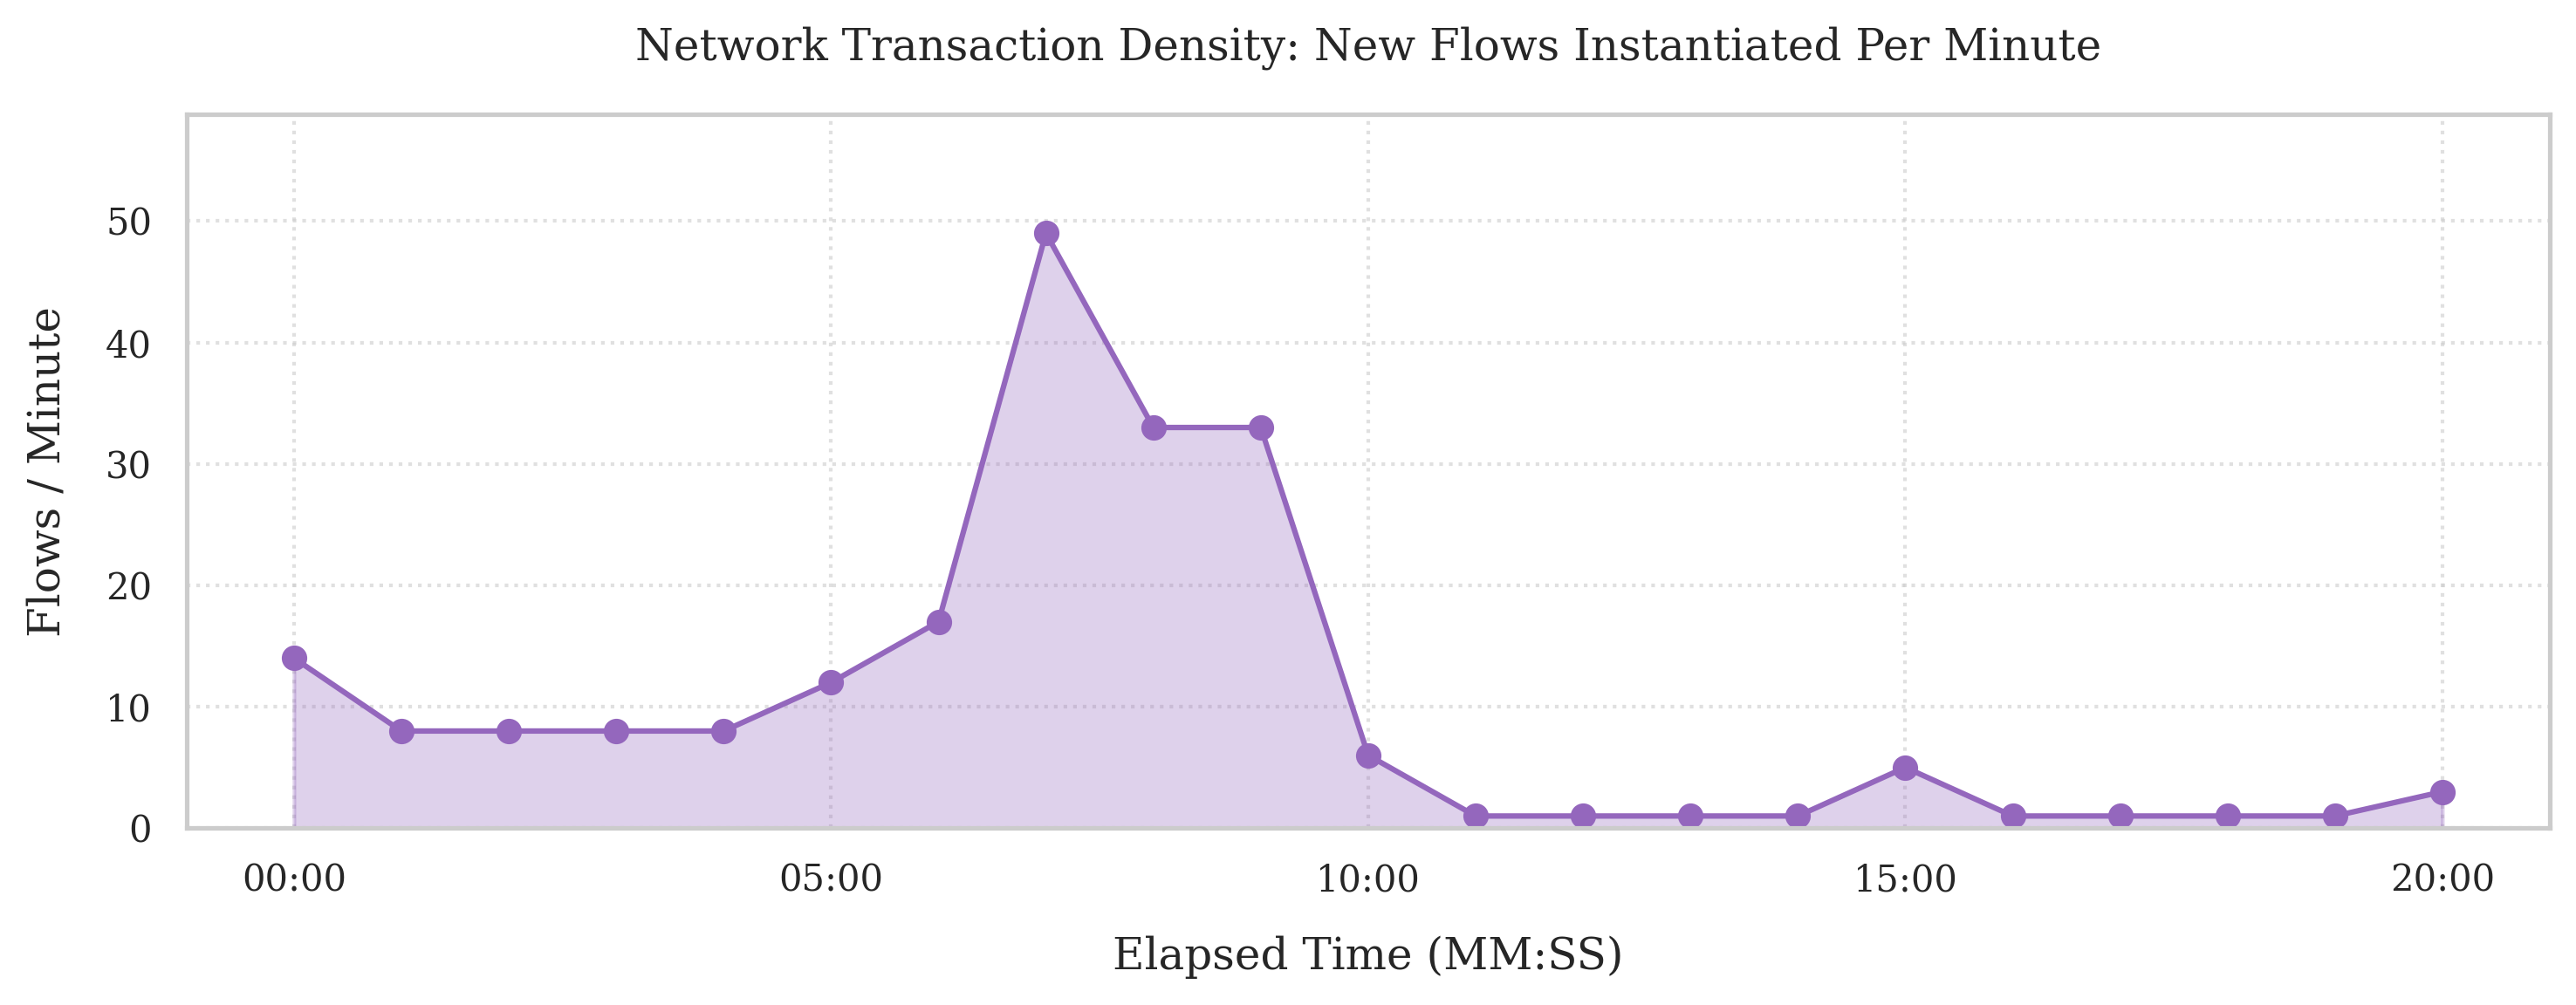

=== NETWORK DENSITY REPORT ===
Average Flows per Minute:      10.10
Peak Flows in a Single Minute: 49


In [31]:
# ==========================================
# 5.2 Network Density (Flows / Minute)
# ==========================================

# Resample to count total flows per minute.
# origin='start' ensures bins are exactly 60 seconds long starting from the very first packet.
flows_per_minute = conn_df['uid'].resample('1min', origin='start').count()

# Apply the '1970' Elapsed Time trick to cleanly format the X-axis
capture_start = conn_df.index.min()
elapsed_time_index = flows_per_minute.index - capture_start + pd.to_datetime('1970-01-01')

# Academic Plotting
fig, ax = plt.subplots(figsize=(10, 4))

# Using a fill_between area chart visually aligns with your Camera Volumetric graph
ax.fill_between(elapsed_time_index, flows_per_minute.values, color='#9467bd', alpha=0.3)
ax.plot(elapsed_time_index, flows_per_minute.values, color='#9467bd', marker='o', linestyle='-', linewidth=1.5)

ax.set_title("Network Transaction Density: New Flows Instantiated Per Minute", pad=15)
ax.set_xlabel("Elapsed Time (MM:SS)", labelpad=10)
ax.set_ylabel("Flows / Minute", labelpad=10)

# Standard matplotlib formatter (no custom functions required)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%M:%S'))

# Add a subtle grid to help the reader track peaks
ax.grid(True, linestyle=':', alpha=0.6)

# Give the chart breathing room on top
top_limit = flows_per_minute.max() * 1.2 if flows_per_minute.max() > 0 else 10
ax.set_ylim(bottom=0, top=top_limit)

plt.tight_layout()
save_figure(fig, "network_flow_density")
plt.show()

# Contextual Output Report
print("=== NETWORK DENSITY REPORT ===")
print(f"Average Flows per Minute:      {flows_per_minute.mean():.2f}")
print(f"Peak Flows in a Single Minute: {flows_per_minute.max():.0f}")

### Traffic Map
We map which devices talk to each other.

In Scenario 4, the thermostat should show unauthorized communication to the camera and attacker IPs.
External endpoints are validated in the botnet indicator sections.

Saved figure: ../../figures/scenario4/topology_traffic_matrix.pdf and ../../figures/scenario4/topology_traffic_matrix.png


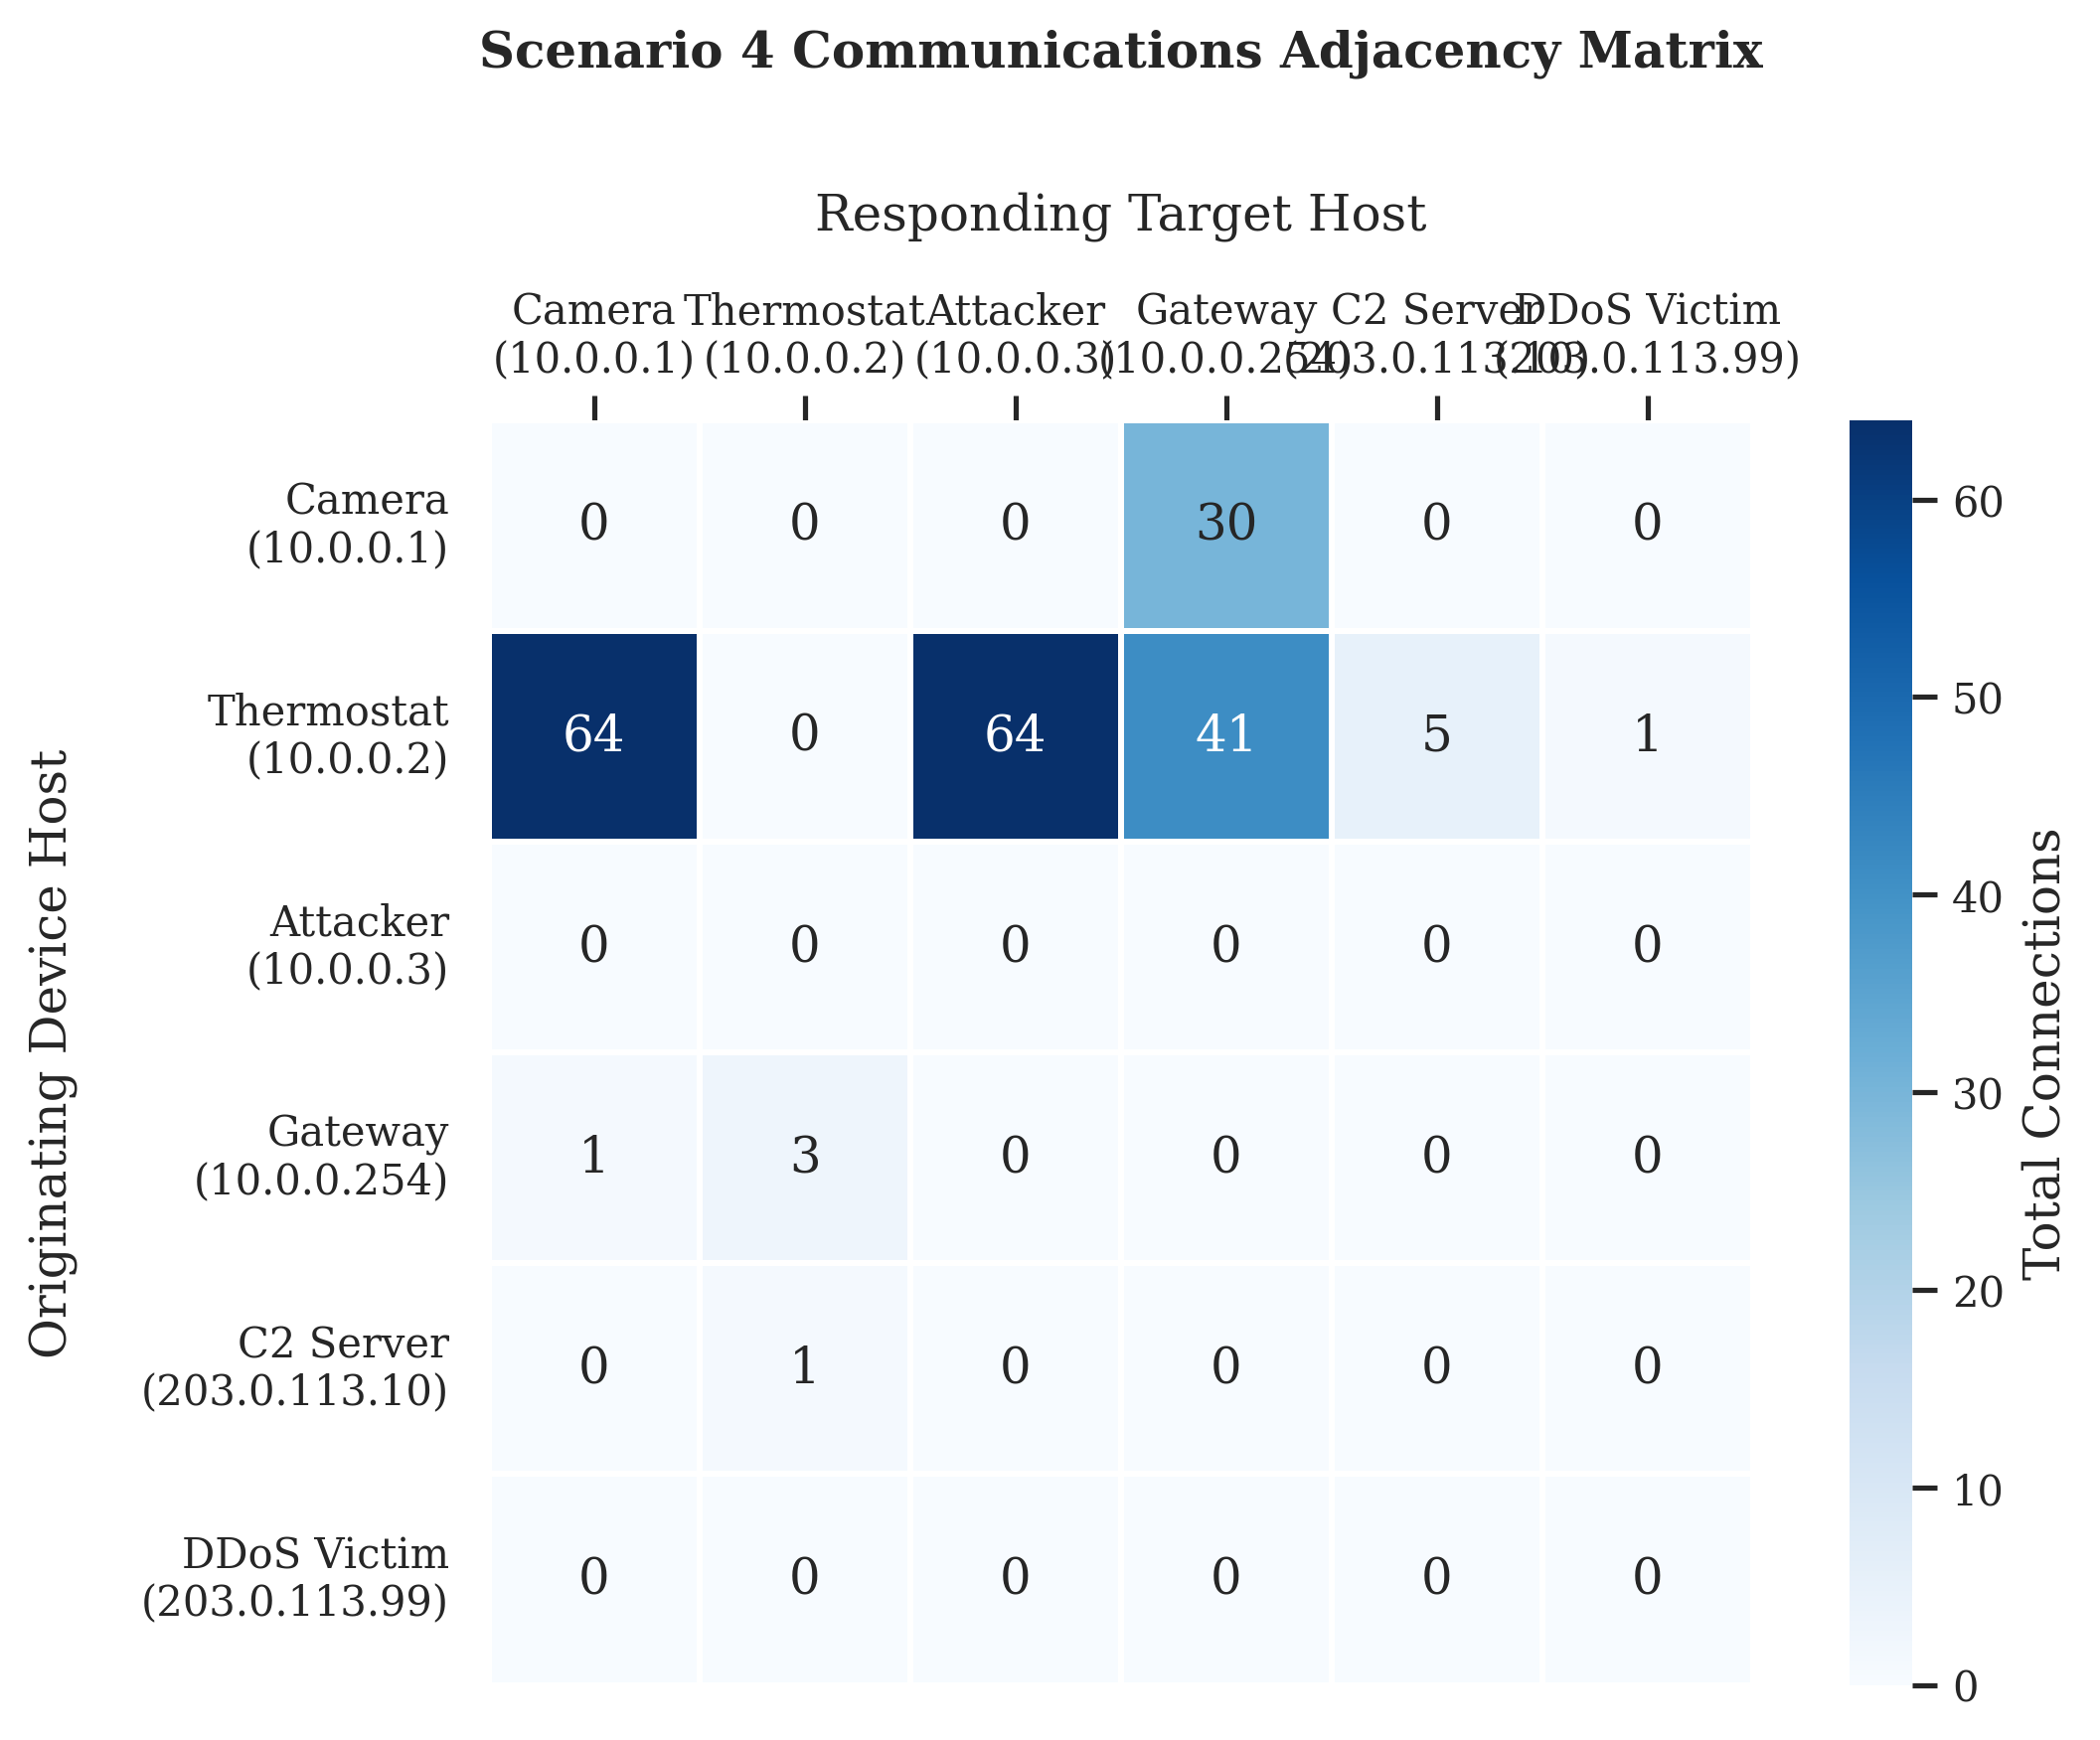

=== TOPOLOGY RULES VALIDATION ===
Lateral communication detected between Camera and Thermostat: 64 flows


In [32]:
# ==========================================
# Topology Matrix (Adjacency Heatmap)
# ==========================================

# Build the raw communication matrix
matrix_data = pd.crosstab(conn_df['id.orig_h'], conn_df['id.resp_h'])

# Ensure all nodes are represented (internal devices + external C2/victim)
for ip in target_ips:
    if ip not in matrix_data.index:
        matrix_data.loc[ip] = 0
    if ip not in matrix_data.columns:
        matrix_data[ip] = 0

# Sort logically to build the matrix flow map
matrix_data = matrix_data.reindex(index=target_ips, columns=target_ips).fillna(0)

# Human-Readable Device Mapping
device_labels = {
    '10.0.0.1': 'Camera\n(10.0.0.1)',
    '10.0.0.2': 'Thermostat\n(10.0.0.2)',
    '10.0.0.3': 'Attacker\n(10.0.0.3)',
    '10.0.0.254': 'Gateway\n(10.0.0.254)',
    '203.0.113.10': 'C2 Server\n(203.0.113.10)',
    '203.0.113.99': 'DDoS Victim\n(203.0.113.99)'
}

# Rename the axes for the heatmap
matrix_data_labeled = matrix_data.rename(index=device_labels, columns=device_labels)

# Academic Plotting
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(matrix_data_labeled, annot=True, fmt=".0f", cmap="Blues", cbar=True, square=True,
            linewidths=1, linecolor='white', cbar_kws={'label': 'Total Connections'}, ax=ax)

# Move the X-axis labels to the top for a more traditional matrix feel
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

ax.set_title("Scenario 4 Communications Adjacency Matrix", pad=30, weight='bold')
ax.set_xlabel("Responding Target Host", labelpad=15)
ax.set_ylabel("Originating Device Host", labelpad=15)

plt.tight_layout()
save_figure(fig, "topology_traffic_matrix")
plt.show()

# ---------------------------------------------------------
# Automated Lateral Movement Validation
# ---------------------------------------------------------
print("=== TOPOLOGY RULES VALIDATION ===")

cam_to_therm = matrix_data.loc['10.0.0.1', '10.0.0.2']
therm_to_cam = matrix_data.loc['10.0.0.2', '10.0.0.1']
lateral_traffic = cam_to_therm + therm_to_cam

if lateral_traffic == 0:
    print("No lateral communication between Camera and Thermostat.")
else:
    print(f"Lateral communication detected between Camera and Thermostat: {lateral_traffic:,.0f} flows")

### DNS Requests
We track DNS lookups over time to see when devices search for their services.

In Scenario 4, the botnet domain should appear alongside authorized IoT endpoints and precede the C2 check-in.

Saved figure: ../../figures/scenario4/dns_query_timeline.pdf and ../../figures/scenario4/dns_query_timeline.png


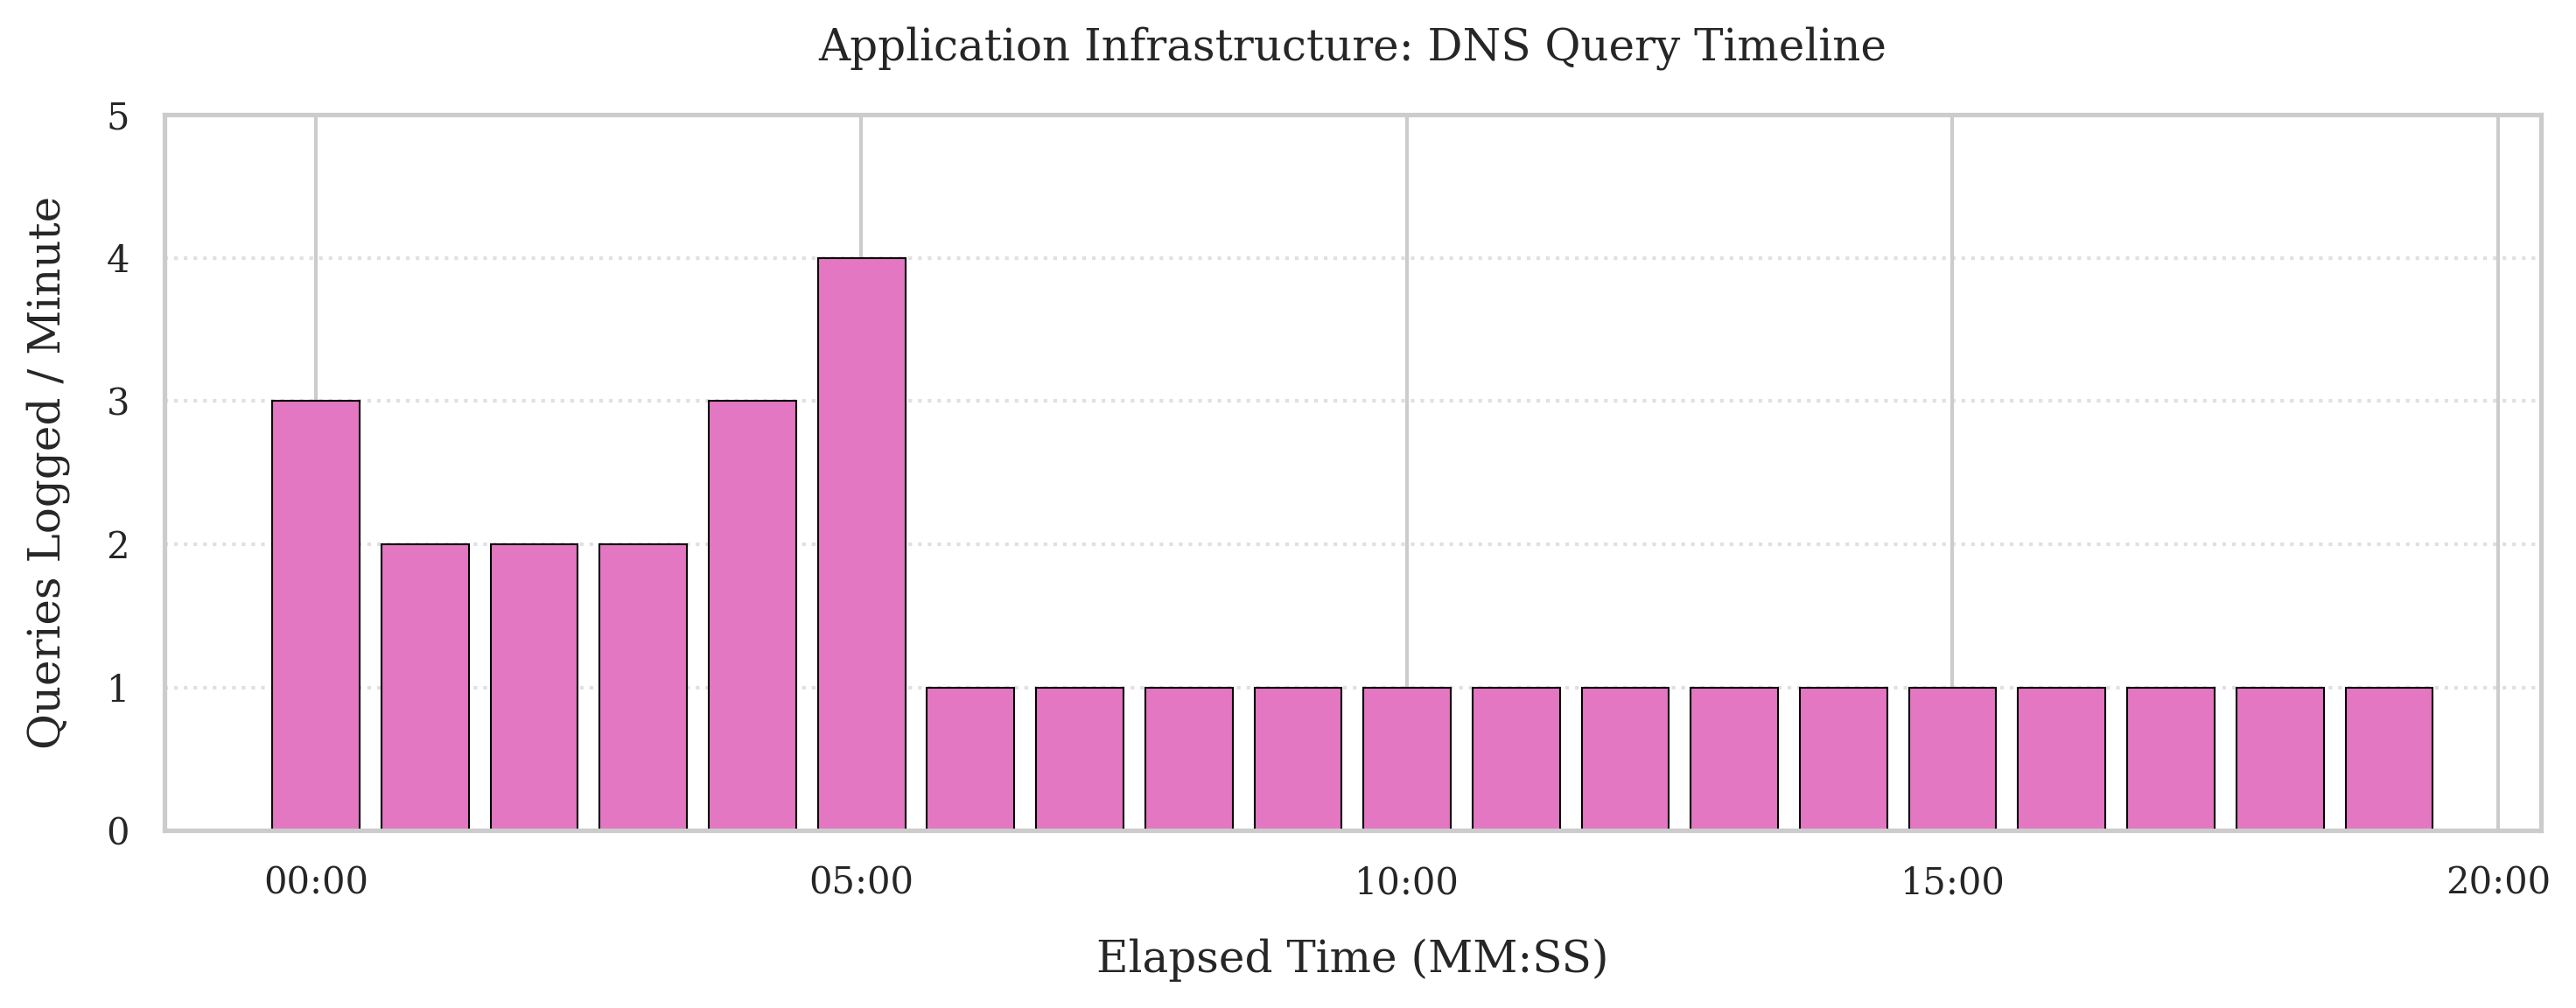

=== DNS QUERY FORENSIC REPORT ===
Total DNS Queries Logged: 30

--- Queried Domains ---
api.smartcamera.com : 21 queries
mqtt.smartthermostat.com : 6 queries
c2.botnet.com : 3 queries

--- Scenario 4 Expectations ---
C2 Domain Detected: c2.botnet.com (3 queries)
No additional unauthorized domains observed.


In [33]:
# ==========================================
# Infrastructure Services (DNS Profiling)
# ==========================================

# Resample DNS query frequency
dns_frequency = dns_df['uid'].resample('1min', origin='start').count()

# Apply the '1970' Elapsed Time trick
capture_start = conn_df.index.min()
elapsed_time_index = dns_frequency.index - capture_start + pd.to_datetime('1970-01-01')

# Academic Plotting
fig, ax = plt.subplots(figsize=(10, 4))

# For a datetime x-axis, width is calculated in days.
# 1 minute = 1/(24*60) days. We multiply by 0.8 to leave gaps between bars.
bar_width = (1 / 1440) * 0.8

ax.bar(elapsed_time_index, dns_frequency.values, width=bar_width, color='#e377c2', edgecolor='black', linewidth=0.5)

ax.set_title("Application Infrastructure: DNS Query Timeline", pad=15)
ax.set_xlabel("Elapsed Time (MM:SS)", labelpad=10)
ax.set_ylabel("Queries Logged / Minute", labelpad=10)

# Standard matplotlib formatter
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%M:%S'))

# Set y-axis to handle the low volume of DNS smoothly (forces integers on Y axis)
ax.yaxis.get_major_locator().set_params(integer=True)
ax.set_ylim(bottom=0, top=max(3, dns_frequency.max() + 1))

# Add a subtle grid
ax.grid(True, axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
save_figure(fig, "dns_query_timeline")
plt.show()

# ---------------------------------------------------------
# Automated Domain Resolution Report
# ---------------------------------------------------------
print("=== DNS QUERY FORENSIC REPORT ===")
print(f"Total DNS Queries Logged: {len(dns_df)}\n")

# Check if the 'query' column exists (standard Zeek dns.log feature)
if 'query' in dns_df.columns:
    print("--- Queried Domains ---")
    domain_counts = dns_df['query'].value_counts()
    for domain, count in domain_counts.items():
        print(f"{domain} : {count} queries")

    print("\n--- Scenario 4 Expectations ---")
    authorized_domains = ['api.smartcamera.com', 'mqtt.smartthermostat.com']
    c2_domain = 'c2.botnet.com'
    unauthorized_domains = domain_counts[~domain_counts.index.isin(authorized_domains + [c2_domain])]

    if c2_domain in domain_counts.index:
        print(f"C2 Domain Detected: {c2_domain} ({domain_counts[c2_domain]} queries)")
    else:
        print("C2 Domain Not Observed: c2.botnet.com")

    if len(unauthorized_domains) == 0:
        print("No additional unauthorized domains observed.")
    else:
        print(f"Additional unauthorized domains observed: {len(unauthorized_domains)}")
else:
    print("Note: 'query' column not found in DataFrame. Ensure Zeek dns.log was parsed correctly.")

### Lateral Target Checks
We search for any traffic where the thermostat targets the camera or attacker IPs.

In Scenario 4, these should be present during the $t=400-600$ lateral propagation phase.

In [34]:
# ==========================================
# Lateral Target Interaction Evidence
# ==========================================

thermostat_ip = '10.0.0.2'
camera_ip = '10.0.0.1'
attacker_ip = '10.0.0.3'

lateral_to_camera = conn_df[
    (conn_df['id.orig_h'] == thermostat_ip) &
    (conn_df['id.resp_h'] == camera_ip)
] .copy()
lateral_to_attacker = conn_df[
    (conn_df['id.orig_h'] == thermostat_ip) &
    (conn_df['id.resp_h'] == attacker_ip)
] .copy()

print("=== LATERAL TARGET SUMMARY ===")
print(f"Thermostat -> Camera flows:   {len(lateral_to_camera)}")
print(f"Thermostat -> Attacker flows: {len(lateral_to_attacker)}\n")

if len(lateral_to_camera) > 0:
    display(lateral_to_camera[['id.orig_h', 'id.resp_h', 'id.resp_p', 'proto', 'conn_state']].head(10))

if len(lateral_to_attacker) > 0:
    display(lateral_to_attacker[['id.orig_h', 'id.resp_h', 'id.resp_p', 'proto', 'conn_state']].head(10))

=== LATERAL TARGET SUMMARY ===
Thermostat -> Camera flows:   64
Thermostat -> Attacker flows: 64



,id.orig_h,id.resp_h,id.resp_p,proto,conn_state
ts,,,,,
2026-05-25 19:03:19.127633095,10.0.0.2,10.0.0.1,22,tcp,REJ
2026-05-25 19:03:19.138581991,10.0.0.2,10.0.0.1,80,tcp,REJ
2026-05-25 19:03:19.151807070,10.0.0.2,10.0.0.1,443,tcp,REJ
2026-05-25 19:03:19.164138079,10.0.0.2,10.0.0.1,3306,tcp,REJ
2026-05-25 19:03:19.174823046,10.0.0.2,10.0.0.1,5432,tcp,REJ
2026-05-25 19:03:19.187417030,10.0.0.2,10.0.0.1,6667,tcp,REJ
2026-05-25 19:03:19.198064089,10.0.0.2,10.0.0.1,8080,tcp,REJ
2026-05-25 19:03:19.208753109,10.0.0.2,10.0.0.1,8883,tcp,REJ
2026-05-25 19:03:45.300725937,10.0.0.2,10.0.0.1,22,tcp,REJ


,id.orig_h,id.resp_h,id.resp_p,proto,conn_state
ts,,,,,
2026-05-25 19:03:19.312145948,10.0.0.2,10.0.0.3,22,tcp,REJ
2026-05-25 19:03:19.324069023,10.0.0.2,10.0.0.3,80,tcp,REJ
2026-05-25 19:03:19.335021019,10.0.0.2,10.0.0.3,443,tcp,REJ
2026-05-25 19:03:19.347075939,10.0.0.2,10.0.0.3,3306,tcp,REJ
2026-05-25 19:03:19.358724117,10.0.0.2,10.0.0.3,5432,tcp,REJ
2026-05-25 19:03:19.369544983,10.0.0.2,10.0.0.3,6667,tcp,REJ
2026-05-25 19:03:19.383369923,10.0.0.2,10.0.0.3,8080,tcp,REJ
2026-05-25 19:03:19.394378901,10.0.0.2,10.0.0.3,8883,tcp,REJ
2026-05-25 19:03:45.489567041,10.0.0.2,10.0.0.3,22,tcp,REJ
